<a href="https://colab.research.google.com/github/CopeliaMinutti94/Katachi-MaNGA-Multimodal/blob/luz%2Fmorfologia-color/notebooks/Katachi_Comparacion_Masas_Pipe3D_Taylor_NSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Etapa 1 — Configuración del entorno y reproducibilidad

### ¿Qué hago?

Configuro el entorno computacional que se utilizará durante el experimento e inicializo una semilla aleatoria base.

En esta etapa también registro las versiones principales del entorno y verifico si PyTorch detecta una GPU.

Todavía no se realiza ningún entrenamiento.

---

### ¿Por qué lo hago?

El objetivo de este experimento es comparar tres definiciones diferentes de masa estelar:

$$
M_{\mathrm{Pipe3D}}, \qquad
M_{\mathrm{Taylor}}, \qquad
M_{\mathrm{NSA}}
$$

Para que la comparación sea válida, las diferencias observadas deberían provenir principalmente del cambio en la etiqueta de masa y no de variaciones accidentales en el procedimiento computacional.

Los experimentos con redes neuronales incluyen diferentes fuentes de aleatoriedad, por ejemplo:

- inicialización de parámetros;
- orden en el que se presentan los datos;
- operaciones realizadas durante el entrenamiento;
- algunas operaciones ejecutadas en GPU.

Por ello, es necesario controlar las principales fuentes de aleatoriedad.

---

### Teoría detrás

Un experimento de aprendizaje automático puede representarse conceptualmente como:

$$
Resultado =
f(Datos,\ Modelo,\ Hiperparámetros,\ Inicialización,\ Aleatoriedad)
$$

En nuestro experimento queremos estudiar principalmente el efecto de cambiar:

$$
Target =
\{M_{\mathrm{Pipe3D}},M_{\mathrm{Taylor}},M_{\mathrm{NSA}}\}
$$

Por lo tanto, debemos mantener controlados, en la medida de lo posible, los demás componentes.

Una **semilla aleatoria** (*random seed*) fija el estado inicial de los generadores de números pseudoaleatorios.

Si utilizamos la misma semilla y las mismas condiciones experimentales, aumentamos la posibilidad de reproducir el mismo resultado.

Sin embargo, una sola semilla no demuestra que un resultado sea robusto. Más adelante se podrán utilizar varias semillas para comprobar si las diferencias entre modelos son consistentes y no producto de una ejecución particularmente favorable.

También se registra el entorno computacional porque la versión de las librerías y el dispositivo utilizado forman parte de la reproducibilidad de un experimento.

---

### ¿Cómo lo implemento?

Se importarán las librerías básicas utilizadas en el análisis y se definirá una función que establezca la misma semilla en:

- Python;
- NumPy;
- PyTorch;
- CUDA, cuando exista una GPU disponible.

Además, se registrará:

- la versión de Python;
- la versión de NumPy;
- la versión de pandas;
- la versión de PyTorch;
- y el dispositivo disponible.

Por ahora no es necesario utilizar una GPU, porque las primeras etapas consistirán en auditoría y comparación de tablas. La GPU será importante posteriormente, cuando se realice el entrenamiento de las redes neuronales.

In [1]:
# ============================================================
# ETAPA 1 — CONFIGURACIÓN DEL ENTORNO Y REPRODUCIBILIDAD
# ============================================================

import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


# ------------------------------------------------------------
# 1. Semilla base del experimento
# ------------------------------------------------------------

SEED_BASE = 42


def fijar_semilla(seed=SEED_BASE):
    """
    Fija las principales fuentes de aleatoriedad utilizadas
    durante el experimento.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        # Favorece reproducibilidad en operaciones de cuDNN.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


fijar_semilla()


# ------------------------------------------------------------
# 2. Dispositivo disponible
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ------------------------------------------------------------
# 3. Registro del entorno computacional
# ------------------------------------------------------------

print("=== ENTORNO COMPUTACIONAL ===")
print(f"Python:  {sys.version.split()[0]}")
print(f"NumPy:   {np.__version__}")
print(f"pandas:  {pd.__version__}")
print(f"PyTorch: {torch.__version__}")

print("\n=== REPRODUCIBILIDAD ===")
print(f"Semilla base: {SEED_BASE}")

print("\n=== DISPOSITIVO ===")
print(f"Dispositivo disponible: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU no disponible actualmente. No es necesaria todavía.")

=== ENTORNO COMPUTACIONAL ===
Python:  3.13.15
NumPy:   2.1.3
pandas:  2.2.3
PyTorch: 2.11.0+cpu

=== REPRODUCIBILIDAD ===
Semilla base: 42

=== DISPOSITIVO ===
Dispositivo disponible: cpu
GPU no disponible actualmente. No es necesaria todavía.


## Etapa 2 — Identificación y carga de las fuentes de datos

### ¿Qué hago?

Identifico y cargo las fuentes de datos necesarias para construir las tres etiquetas de masa estelar que se compararán en el experimento.

En esta etapa se utilizarán dos tablas principales:

1. **Tabla proporcionada por los asesores (`color_morp_1.csv`)**
   - `MANGAID`: identificador de la galaxia.
   - `T_11`: clasificación morfológica.
   - `g_i`: color fotométrico.
   - `LogMassTaylor`: estimación de masa basada en Taylor et al.
   - `LogMassNSA`: estimación de masa proveniente del NASA-Sloan Atlas.

2. **Catálogo de Katachi (`scalars.cat`)**
   - `mangaid`: identificador de la galaxia.
   - `log_mstar`: masa estelar utilizada originalmente por Katachi, obtenida de Pipe3D.
   - `split`: partición original de Katachi (`Train` o `Test`).

Por ahora no se utilizarán las imágenes. Primero se estudiarán las etiquetas.

---

### ¿Por qué lo hago?

Antes de construir un modelo es necesario conocer exactamente:

- de dónde proviene cada variable;
- qué identificador permite unir las tablas;
- si las columnas necesarias realmente existen;
- cuántas observaciones contiene cada fuente;
- y si los datos fueron cargados correctamente.

Una comparación de modelos puede ser incorrecta si se asume que dos tablas representan las mismas galaxias sin verificar explícitamente su correspondencia.

Además, queremos separar dos problemas:

1. **Ingeniería de datos:** construir correctamente la muestra experimental.
2. **Modelado:** entrenar posteriormente la red neuronal.

Primero debe resolverse el problema de datos.

---

### Teoría detrás

En aprendizaje supervisado, cada observación puede representarse como:

$$
(x_i,y_i)
$$

donde:

- $x_i$ representa la entrada del modelo;
- $y_i$ representa la etiqueta que se desea predecir.

En nuestro caso, más adelante:

$$
x_i = \mathrm{imagen\ gri\ de\ la\ galaxia}
$$

pero tendremos tres posibles etiquetas:

$$
y_i^{Pipe3D}, \qquad y_i^{Taylor}, \qquad y_i^{NSA}
$$

Para comparar estas etiquetas de manera controlada, primero debemos asegurarnos de que correspondan al mismo objeto astronómico.

La variable que permitirá establecer esa correspondencia será:

$$
\mathrm{MANGAID}
$$

Este proceso se conoce como **data integration** o integración de datos.

Un error en la correspondencia entre identificadores produciría un caso extremo de *label corruption*: el modelo podría recibir la imagen de una galaxia asociada con la masa de otra galaxia.

Por ello, la validación de identificadores se realiza antes de cualquier entrenamiento.

---

### ¿Cómo lo implemento?

1. Se cargará `color_morp_1.csv`, proporcionado por los asesores.
2. Se descargará el catálogo `scalars.cat` utilizado por Katachi.
3. Se inspeccionarán:
   - dimensiones;
   - nombres de columnas;
   - primeras observaciones;
   - tipos de datos.
4. Se verificará explícitamente que existan las variables mínimas necesarias.

En esta etapa todavía no se eliminarán valores faltantes ni se construirán las muestras Train, Validation o Test.

In [2]:
# ============================================================
# ETAPA 2.1 — CARGA DE LA TABLA PROPORCIONADA POR LOS ASESORES
# ============================================================

from google.colab import files

print("Selecciona el archivo: color_morp_1.csv")

uploaded = files.upload()

# Buscar automáticamente el CSV subido
archivos_csv = [
    nombre for nombre in uploaded.keys()
    if nombre.lower().endswith(".csv")
]

if len(archivos_csv) == 0:
    raise FileNotFoundError("No se encontró ningún archivo CSV.")

archivo_color_morp = archivos_csv[0]

color_morp = pd.read_csv(archivo_color_morp)

print("\n=== TABLA DE ASESORES ===")
print(f"Archivo: {archivo_color_morp}")
print(f"Filas:    {color_morp.shape[0]}")
print(f"Columnas: {color_morp.shape[1]}")

print("\n=== COLUMNAS ===")
print(color_morp.columns.tolist())

print("\n=== PRIMERAS 5 GALAXIAS ===")
display(color_morp.head())

Selecciona el archivo: color_morp_1.csv


Saving color_morp_2.csv to color_morp_2.csv

=== TABLA DE ASESORES ===
Archivo: color_morp_2.csv
Filas:    10126
Columnas: 6

=== COLUMNAS ===
['name', 'MANGAID', 'T_11', 'g_i', 'LogMassTaylor', 'LogMassNSA']

=== PRIMERAS 5 GALAXIAS ===


,name,MANGAID,T_11,g_i,LogMassTaylor,LogMassNSA
0,manga-10001-12701,1-48157,4,0.404967,9.269490,9.486857
1,manga-10001-12702,1-48188,4,0.644865,9.514213,9.727675
2,manga-10001-12703,1-55648,4,0.710236,9.944890,10.136514
3,manga-10001-12704,1-55616,7,0.766408,9.561902,9.632117
4,manga-10001-12705,1-55784,4,0.574194,9.977346,10.113519


In [3]:
# ============================================================
# ETAPA 2.2 — VERIFICACIÓN DE VARIABLES NECESARIAS
# ============================================================

columnas_requeridas_asesores = [
    "MANGAID",
    "LogMassTaylor",
    "LogMassNSA"
]

faltantes = [
    columna
    for columna in columnas_requeridas_asesores
    if columna not in color_morp.columns
]

if faltantes:
    raise ValueError(
        f"Faltan columnas necesarias en la tabla: {faltantes}"
    )

print("✓ La tabla contiene las variables necesarias.")
print()

print("Tipos de datos:")
print(
    color_morp[
        ["MANGAID", "LogMassTaylor", "LogMassNSA"]
    ].dtypes
)

✓ La tabla contiene las variables necesarias.

Tipos de datos:
MANGAID           object
LogMassTaylor    float64
LogMassNSA       float64
dtype: object


## Etapa 2.3 — Carga de la masa estelar utilizada originalmente por Katachi

### ¿Qué hago?

Cargo el catálogo `scalars.cat` distribuido por Katachi e identifico las variables necesarias para nuestro experimento:

- `mangaid`: identificador de la galaxia;
- `log_mstar`: masa estelar utilizada como etiqueta original en Katachi;
- `split`: partición original de la galaxia en Train o Test.

Esta será la tercera estimación de masa que compararemos con `LogMassTaylor` y `LogMassNSA`.

---

### ¿Por qué lo hago?

Hasta ahora tenemos dos estimaciones de masa en la tabla proporcionada por los asesores:

$$
\log M_{\mathrm{Taylor}}
$$

y

$$
\log M_{\mathrm{NSA}}
$$

Pero la pregunta experimental requiere compararlas con la masa que utilizó originalmente Katachi:

$$
\log M_{\mathrm{Pipe3D}}
$$

Por ello necesitamos recuperar del catálogo original tanto la etiqueta `log_mstar` como la partición `split`.

La partición original es especialmente importante porque no queremos crear un Test completamente nuevo y mezclar galaxias que Katachi ya utilizó durante entrenamiento.

---

### Teoría detrás

En aprendizaje supervisado, la evaluación debe hacerse con observaciones que no participaron en el ajuste del modelo.

Conceptualmente:

$$
D = D_{\mathrm{Train}} \cup D_{\mathrm{Validation}} \cup D_{\mathrm{Test}}
$$

con:

$$
D_{\mathrm{Train}} \cap D_{\mathrm{Test}} = \varnothing
$$

El conjunto de Test funciona como una estimación independiente de la capacidad de generalización.

Si redistribuyéramos aleatoriamente todas las galaxias de Katachi, algunas galaxias utilizadas anteriormente durante entrenamiento podrían terminar en nuestro nuevo Test, produciendo una comparación metodológicamente distinta y potencialmente contaminada.

Por eso se preservará el `split` original de Katachi.

Además, para comparar Pipe3D, Taylor y NSA de manera justa, posteriormente construiremos una cohorte en la que las tres masas correspondan exactamente a los mismos `MANGAID`.

---

### ¿Cómo lo implemento?

Se descargará el catálogo público `scalars.cat` de Katachi y se cargará como un DataFrame.

Después se comprobará que contiene las tres variables mínimas:

- `mangaid`;
- `log_mstar`;
- `split`.

En esta etapa todavía no se realizará el cruce con la tabla de los asesores.

In [4]:
# ============================================================
# ETAPA 2.3 — CARGA DEL CATÁLOGO ORIGINAL DE KATACHI
# ============================================================

!pip install -q hickle

import os
import hickle as hkl

url_scalars = (
    "https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/"
    "Katachi_MaNGA_Catalogues/scalars.cat"
)

archivo_scalars = "/content/scalars.cat"

# Descargar solo si todavía no existe
if not os.path.exists(archivo_scalars):
    print("Descargando scalars.cat...")
    !wget -q --show-progress "$url_scalars" -O "$archivo_scalars"
else:
    print("scalars.cat ya existe en el entorno.")

# Cargar catálogo
scalars = hkl.load(archivo_scalars)

print("\n=== CATÁLOGO KATACHI ===")
print(f"Tipo de objeto: {type(scalars)}")
print(f"Filas:           {scalars.shape[0]}")
print(f"Columnas:        {scalars.shape[1]}")

print("\n=== COLUMNAS DISPONIBLES ===")
print(scalars.columns.tolist())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 3.1 MB/s eta 0:00:00
Descargando scalars.cat...
/content/scalars.ca 100%[===================>] 153.52M  21.1MB/s    in 8.8s    

=== CATÁLOGO KATACHI ===
Tipo de objeto: <class 'pandas.core.frame.DataFrame'>
Filas:           10081
Columnas:        30

=== COLUMNAS DISPONIBLES ===
['mangaid', 'log_mstar', 'log_sfr', 'redshift', 'redshift_gz', 'sersic_n', 't50_Pipe3D', 't50_model', 'd4000', 'Av', 'Z', 'spirals', 'bars', 'irregular_features', 'edge_on', 'bulge', 'RA_Pipe3D', 'DEC_Pipe3D', 'RA_gz', 'DEC_gz', 'smooth', 'merger_gz', 'p_merger', 'over_density', 'z_completeness', 'split', 'pred_mstar', 'pred_sfr', 'pred_d4000', 'sfh']


In [5]:
# ============================================================
# ETAPA 2.4 — VALIDACIÓN DE VARIABLES DE KATACHI
# ============================================================

columnas_requeridas_katachi = [
    "mangaid",
    "log_mstar",
    "split"
]

faltantes_katachi = [
    columna
    for columna in columnas_requeridas_katachi
    if columna not in scalars.columns
]

if faltantes_katachi:
    raise ValueError(
        f"Faltan columnas necesarias en scalars.cat: {faltantes_katachi}"
    )

print("✓ El catálogo de Katachi contiene las variables necesarias.")

print("\nTipos de datos:")
print(
    scalars[
        ["mangaid", "log_mstar", "split"]
    ].dtypes
)

print("\nPrimeras 5 observaciones:")
display(
    scalars[
        ["mangaid", "log_mstar", "split"]
    ].head()
)

✓ El catálogo de Katachi contiene las variables necesarias.

Tipos de datos:
mangaid       object
log_mstar    float64
split         object
dtype: object

Primeras 5 observaciones:


,mangaid,log_mstar,split
0,1-1009,11.178438,Train
1,1-10166,11.513323,Train
2,1-10177,10.615028,Train
3,1-10263,9.305632,Train
4,1-1033,9.172108,Train


## Etapa 3 — Auditoría de calidad de las etiquetas de masa

### ¿Qué hago?

Evalúo individualmente la calidad básica de las tres variables que posteriormente serán utilizadas como etiquetas de regresión:

- `log_mstar` de Katachi/Pipe3D;
- `LogMassTaylor`;
- `LogMassNSA`.

Para cada una se revisará:

- número total de registros;
- valores faltantes (`NaN`);
- valores infinitos;
- número de valores numéricamente válidos;
- mínimo;
- máximo;
- media;
- mediana;
- desviación estándar.

También se comprobará si existen identificadores de galaxia duplicados en cada catálogo y se revisará la distribución del `split` original de Katachi.

En esta etapa **no se eliminará ningún registro**.

---

### ¿Por qué lo hago?

Una red neuronal aprende a aproximar las etiquetas proporcionadas durante el entrenamiento.

Por ello, antes de analizar el desempeño del modelo, necesitamos conocer la calidad de las variables objetivo.

Si una etiqueta contiene:

- valores faltantes;
- valores infinitos;
- errores extremos;
- identificadores repetidos;
- o valores fuera de un rango físicamente razonable,

estos problemas podrían propagarse al entrenamiento.

Además, eliminar observaciones automáticamente sin estudiar primero por qué presentan problemas puede introducir un sesgo de selección.

Por eso, primero se realiza una auditoría descriptiva y solamente después se decide qué criterios de limpieza son necesarios.

---

### Teoría detrás

En aprendizaje supervisado se supone que cada ejemplo de entrenamiento tiene una correspondencia válida:

$$
(x_i,y_i)
$$

donde $x_i$ es la entrada y $y_i$ la etiqueta.

Si la etiqueta contiene ruido o errores, podemos representar conceptualmente la observación como:

$$
y_i^{obs} = y_i^{true} + \epsilon_i
$$

donde $\epsilon_i$ representa errores de medición, incertidumbre metodológica o problemas en los datos.

En nuestro experimento este punto es especialmente importante porque Pipe3D, Taylor y NSA no son mediciones directas de una "masa verdadera", sino diferentes **estimaciones de la masa estelar**.

Por ello, parte de la dispersión que posteriormente observe la CNN puede estar relacionada con las propias características de las etiquetas.

También es necesario verificar la unicidad de los identificadores.

Idealmente debe existir una relación:

$$
\mathrm{MANGAID} \rightarrow \mathrm{una\ galaxia}
$$

Si un mismo identificador apareciera varias veces con diferentes masas, la correspondencia dejaría de ser unívoca y tendríamos que investigar el motivo antes del entrenamiento.

---

### ¿Cómo lo implemento?

Se construirá una función de auditoría que reciba una columna de masa y calcule automáticamente indicadores básicos de calidad.

La función se aplicará por separado a:

1. `log_mstar`;
2. `LogMassTaylor`;
3. `LogMassNSA`.

También se contarán identificadores duplicados en ambas tablas y se inspeccionarán las categorías presentes en `split`.

Por ahora los resultados serán únicamente diagnósticos; no se modificarán los DataFrames originales.

In [6]:
# ============================================================
# ETAPA 3 — AUDITORÍA DE CALIDAD DE LAS ETIQUETAS
# ============================================================

def auditar_masa(serie, nombre):
    """
    Genera un resumen de calidad para una variable de masa.
    No modifica los datos originales.
    """

    valores = serie.to_numpy(dtype=float)

    n_total = len(valores)
    n_nan = np.isnan(valores).sum()
    n_inf = np.isinf(valores).sum()

    mascara_finita = np.isfinite(valores)
    valores_validos = valores[mascara_finita]

    resumen = {
        "masa": nombre,
        "N_total": n_total,
        "N_NaN": int(n_nan),
        "N_inf": int(n_inf),
        "N_validos": int(mascara_finita.sum()),
        "min": np.min(valores_validos) if len(valores_validos) > 0 else np.nan,
        "max": np.max(valores_validos) if len(valores_validos) > 0 else np.nan,
        "media": np.mean(valores_validos) if len(valores_validos) > 0 else np.nan,
        "mediana": np.median(valores_validos) if len(valores_validos) > 0 else np.nan,
        "std": np.std(valores_validos, ddof=1) if len(valores_validos) > 1 else np.nan
    }

    return resumen


# ------------------------------------------------------------
# 1. Auditoría de las tres masas
# ------------------------------------------------------------

resumen_masas = pd.DataFrame([
    auditar_masa(
        scalars["log_mstar"],
        "Pipe3D / Katachi"
    ),
    auditar_masa(
        color_morp["LogMassTaylor"],
        "Taylor"
    ),
    auditar_masa(
        color_morp["LogMassNSA"],
        "NSA"
    )
])

print("=== AUDITORÍA DE LAS TRES ETIQUETAS ===")
display(resumen_masas.round(4))


# ------------------------------------------------------------
# 2. Verificación de identificadores duplicados
# ------------------------------------------------------------

duplicados_katachi = scalars["mangaid"].duplicated().sum()
duplicados_asesores = color_morp["MANGAID"].duplicated().sum()

print("\n=== IDENTIFICADORES DUPLICADOS ===")
print(f"Katachi / scalars.cat: {duplicados_katachi}")
print(f"Tabla de asesores:     {duplicados_asesores}")


# ------------------------------------------------------------
# 3. Revisar el split original de Katachi
# ------------------------------------------------------------

print("\n=== SPLIT ORIGINAL DE KATACHI ===")
print(
    scalars["split"]
    .value_counts(dropna=False)
)

=== AUDITORÍA DE LAS TRES ETIQUETAS ===


,masa,N_total,N_NaN,N_inf,N_validos,min,max,media,mediana,std
0,Pipe3D / Katachi,10081,0,0,10081,5.9202,17.7251,10.6144,10.6545,0.6805
1,Taylor,10126,1302,0,8824,-2888.5985,19.1794,4.9046,10.0949,123.3361
2,NSA,10126,28,0,10098,5.9125,13.3904,10.1618,10.1934,0.7189



=== IDENTIFICADORES DUPLICADOS ===
Katachi / scalars.cat: 0
Tabla de asesores:     0

=== SPLIT ORIGINAL DE KATACHI ===
split
Train    8914
Test      990
None      177
Name: count, dtype: int64


## Etapa 4 — Diagnóstico de valores anómalos en las estimaciones de masa

### ¿Qué hago?

Investigo los valores extremos encontrados durante la auditoría de las tres etiquetas de masa, con especial atención a `LogMassTaylor`.

La auditoría inicial mostró que:

- Pipe3D contiene algunos valores de masa extremadamente altos;
- NSA presenta pocos valores faltantes y un rango relativamente estable;
- Taylor contiene valores extremadamente negativos que alteran fuertemente su media y desviación estándar.

En esta etapa no se eliminarán observaciones.

Primero se identificarán las galaxias responsables de estos extremos y se estudiará su relación con otras variables disponibles, particularmente `g_i`.

---

### ¿Por qué lo hago?

Un valor extremo puede tener diferentes orígenes:

1. puede ser una observación físicamente real;
2. puede provenir de una medición fotométrica problemática;
3. puede ser consecuencia de una operación matemática sobre datos inválidos;
4. puede representar un valor especial utilizado por un catálogo;
5. puede ser un error de procesamiento.

Eliminar automáticamente un valor extremo sin conocer su origen puede introducir sesgo en la muestra.

Por ello, una regla de limpieza debe estar sustentada por el significado de los datos y no solamente por su magnitud.

---

### Teoría detrás

Las estadísticas como la media y la desviación estándar son sensibles a valores extremos.

Por ejemplo, para un conjunto de valores:

$$
x_1,x_2,\ldots,x_n
$$

la media se calcula como:

$$
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

Un número extremadamente grande o pequeño puede modificar significativamente esta cantidad.

La mediana, en cambio, depende de la posición central de los datos y es mucho más robusta frente a valores extremos.

Esto explica por qué para Taylor encontramos simultáneamente:

$$
\mathrm{media}\approx 4.9
$$

pero:

$$
\mathrm{mediana}\approx 10.1
$$

La gran diferencia entre ambas estadísticas indica que la distribución está siendo afectada por observaciones extremas.

En problemas de aprendizaje supervisado, estos valores son especialmente importantes porque una función de pérdida cuadrática como MSE penaliza el error como:

$$
(y-\hat{y})^2
$$

Por lo tanto, una etiqueta extremadamente anómala podría dominar de manera desproporcionada el proceso de optimización.

---

### ¿Cómo lo implemento?

Se identificarán:

- los valores más pequeños y más grandes de `LogMassTaylor`;
- los valores más pequeños y más grandes de `LogMassNSA`;
- los valores más pequeños y más grandes de `log_mstar`.

Para Taylor se mostrarán también `g_i`, `T_11` y `MANGAID`, con el objetivo de determinar si las masas extremas están asociadas con valores fotométricos anómalos.

No se aplicará todavía ningún filtro.

In [7]:
# ============================================================
# ETAPA 4 — DIAGNÓSTICO DE VALORES EXTREMOS
# ============================================================

print("=== TAYLOR: 15 VALORES MÁS PEQUEÑOS ===")

display(
    color_morp[
        ["MANGAID", "T_11", "g_i", "LogMassTaylor", "LogMassNSA"]
    ]
    .sort_values("LogMassTaylor", ascending=True)
    .head(15)
)


print("\n=== TAYLOR: 15 VALORES MÁS GRANDES ===")

display(
    color_morp[
        ["MANGAID", "T_11", "g_i", "LogMassTaylor", "LogMassNSA"]
    ]
    .sort_values("LogMassTaylor", ascending=False)
    .head(15)
)


print("\n=== PIPE3D: 15 VALORES MÁS PEQUEÑOS ===")

display(
    scalars[
        ["mangaid", "log_mstar", "split"]
    ]
    .sort_values("log_mstar", ascending=True)
    .head(15)
)


print("\n=== PIPE3D: 15 VALORES MÁS GRANDES ===")

display(
    scalars[
        ["mangaid", "log_mstar", "split"]
    ]
    .sort_values("log_mstar", ascending=False)
    .head(15)
)


print("\n=== NSA: 15 VALORES MÁS PEQUEÑOS ===")

display(
    color_morp[
        ["MANGAID", "g_i", "LogMassTaylor", "LogMassNSA"]
    ]
    .sort_values("LogMassNSA", ascending=True)
    .head(15)
)


print("\n=== NSA: 15 VALORES MÁS GRANDES ===")

display(
    color_morp[
        ["MANGAID", "g_i", "LogMassTaylor", "LogMassNSA"]
    ]
    .sort_values("LogMassNSA", ascending=False)
    .head(15)
)

=== TAYLOR: 15 VALORES MÁS PEQUEÑOS ===


,MANGAID,T_11,g_i,LogMassTaylor,LogMassNSA
9311,40-10,-2,2099.54500,-2888.598500,NaN
8720,34-30,5,2099.55578,-2888.596850,NaN
5892,50-13,-5,2099.55774,-2888.596550,NaN
157,59-57,3,2099.57930,-2888.593250,NaN
5891,50-12,-2,2099.61948,-2888.587100,NaN
9135,41-95,1,2099.67828,-2888.578100,NaN
8557,46-287,-2,2099.68024,-2888.577800,NaN
5895,50-6,-2,2099.71356,-2888.572700,NaN
7063,43-22,9,2099.71454,-2888.572550,NaN
717,59-4,3,2099.72091,-2888.571575,NaN



=== TAYLOR: 15 VALORES MÁS GRANDES ===


,MANGAID,T_11,g_i,LogMassTaylor,LogMassNSA
8139,1-314409,3,49.534275,19.179408,11.704529
6692,1-176803,-5,49.665756,19.138543,11.697855
840,1-180998,3,49.402625,18.890472,11.376834
2341,1-325495,7,49.334026,18.846952,11.650258
5882,1-256832,0,49.605087,18.787894,11.295615
10028,1-375452,3,49.487893,18.782606,11.329304
8271,1-268479,2,49.531885,18.775070,11.395176
453,1-80332,-5,49.606628,18.705347,11.329613
5641,1-487379,3,49.546612,18.702697,11.269893
4200,1-548024,3,49.387634,18.607147,11.204299



=== PIPE3D: 15 VALORES MÁS PEQUEÑOS ===


...

,mangaid,log_mstar,split
1033,1-150768,17.725087,Train
9358,1-635474,16.773685,Test
4160,1-286795,16.594001,None
2795,1-235203,16.306554,Train
5429,1-368606,14.921592,Train
7392,1-45787,12.177967,Train
4390,1-298228,12.121987,Train
516,1-123194,12.118704,Train
432,1-121546,12.090487,Train
598,1-134760,12.065315,Train



=== NSA: 15 VALORES MÁS PEQUEÑOS ===


,MANGAID,g_i,LogMassTaylor,LogMassNSA
1769,1-609067,0.604857,10.636207,5.912527
1137,1-591845,NaN,NaN,7.221067
6290,1-338579,0.944242,7.159701,7.249032
9240,1-298466,NaN,-3.789757,7.269048
421,1-230783,NaN,-6.978012,7.420330
4467,1-389720,NaN,NaN,7.574498
6171,1-619066,NaN,NaN,7.786251
8830,1-153248,0.831268,9.140696,7.840501
8566,1-295506,NaN,NaN,7.840735
3975,1-604048,NaN,-1.195411,7.961987



=== NSA: 15 VALORES MÁS GRANDES ===


,MANGAID,g_i,LogMassTaylor,LogMassNSA
9242,1-298366,NaN,NaN,13.390363
4880,1-256301,1.373537,13.334780,12.852285
4587,1-312838,NaN,NaN,12.533710
5086,1-283711,0.390619,11.847629,12.411588
1549,1-543765,1.338363,12.615652,12.297423
5729,1-254532,NaN,NaN,12.132048
4179,1-338090,0.794984,11.964849,12.060917
7259,1-45787,0.980667,11.920454,11.961790
1270,1-123194,1.033408,11.993371,11.947730
286,1-352560,0.925054,11.808415,11.865576


## Etapa 5 — Relación entre la calidad fotométrica y la masa de Taylor

### ¿Qué hago?

Analizo cuantitativamente si los valores anómalos de `LogMassTaylor` están relacionados con problemas en la variable fotométrica `g_i`.

Para ello, las galaxias se clasificarán según el estado de `g_i` en tres grupos:

- valor disponible y no mayor que 2;
- valor faltante (`NaN`);
- valor mayor que 2.

Los valores negativos de `g_i` no se eliminarán, ya que previamente se estableció que pueden ser valores válidos.

Después se estudiará la distribución de `LogMassTaylor` dentro de cada uno de estos grupos.

En esta etapa todavía no se eliminarán galaxias ni se modificará la tabla original.

---

### ¿Por qué lo hago?

La inspección de los valores extremos mostró que las masas Taylor extremadamente grandes o pequeñas coinciden frecuentemente con valores anómalos de `g_i`.

Sin embargo, una inspección visual de unas pocas filas no es suficiente para establecer una regla de calidad.

Necesitamos cuantificar:

- cuántas galaxias pertenecen a cada estado fotométrico;
- cuántas poseen una masa Taylor disponible;
- qué rango de masas Taylor presenta cada grupo;
- y cuánto cambia su distribución cuando la fotometría es válida.

Esto permitirá determinar si los valores extremos son casos aislados o si existe una relación sistemática con la calidad fotométrica.

---

### Teoría detrás

La estimación de masa de Taylor está relacionada con observables fotométricos.

De forma simplificada, Taylor et al. establece una relación entre masa estelar, color rest-frame y luminosidad en banda i:

$$
\log(M_*/M_\odot)
=
-0.68
+
0.70(g-i)
-
0.4M_i
$$

Por lo tanto, una anomalía en las variables fotométricas utilizadas para construir la masa puede propagarse a la etiqueta final.

En ingeniería de datos esto se denomina **propagación de errores**:

$$
Datos\ de\ entrada\ problemáticos
\rightarrow
Variable\ derivada\ problemática
$$

Esto es especialmente importante en aprendizaje supervisado porque la variable derivada se utilizará posteriormente como `target`.

Una red neuronal no sabe si una etiqueta es físicamente razonable. Si recibe un valor incorrecto, intentará aprenderlo de la misma manera que cualquier otra observación.

Por ello, la calidad de las etiquetas debe estudiarse antes del entrenamiento.

---

### ¿Cómo lo implemento?

Se construirá una variable diagnóstica denominada `estado_gi` sin modificar `g_i`.

Las categorías serán:

- `valido`: `g_i` disponible y `g_i <= 2`;
- `NaN`: valor faltante;
- `mayor_2`: `g_i > 2`.

Posteriormente se calcularán estadísticas descriptivas de `LogMassTaylor` dentro de cada categoría.

También se contarán valores Taylor muy extremos únicamente como diagnóstico, sin utilizarlos todavía como criterio de eliminación.

In [8]:
# ============================================================
# ETAPA 5 — RELACIÓN ENTRE g_i Y LogMassTaylor
# ============================================================

# Trabajamos sobre una copia para no modificar la tabla original
diag_taylor = color_morp.copy()


# ------------------------------------------------------------
# 1. Clasificar el estado de g_i
# ------------------------------------------------------------

diag_taylor["estado_gi"] = np.select(
    [
        diag_taylor["g_i"].isna(),
        diag_taylor["g_i"] > 2
    ],
    [
        "NaN",
        "mayor_2"
    ],
    default="valido"
)


print("=== ESTADO DE g_i ===")
print(
    diag_taylor["estado_gi"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# 2. Estadísticas de Taylor según calidad de g_i
# ------------------------------------------------------------

resumen_taylor_gi = (
    diag_taylor
    .groupby("estado_gi", observed=True)["LogMassTaylor"]
    .agg(
        N_total="size",
        N_Taylor_disponible="count",
        minimo="min",
        mediana="median",
        media="mean",
        maximo="max",
        desviacion="std"
    )
)

print("\n=== LogMassTaylor SEGÚN ESTADO DE g_i ===")
display(resumen_taylor_gi.round(4))


# ------------------------------------------------------------
# 3. Diagnóstico de valores extremos de Taylor
#
# IMPORTANTE:
# Los límites siguientes NO son filtros.
# Solo sirven para contar valores claramente alejados
# de la región principal de la distribución.
# ------------------------------------------------------------

diag_taylor["Taylor_menor_5"] = (
    diag_taylor["LogMassTaylor"] < 5
)

diag_taylor["Taylor_mayor_15"] = (
    diag_taylor["LogMassTaylor"] > 15
)


tabla_extremos = pd.crosstab(
    diag_taylor["estado_gi"],
    [
        diag_taylor["Taylor_menor_5"],
        diag_taylor["Taylor_mayor_15"]
    ]
)

print("\n=== DIAGNÓSTICO DE EXTREMOS DE TAYLOR ===")
print("Los umbrales 5 y 15 son SOLO diagnósticos, no filtros.")
display(tabla_extremos)


# ------------------------------------------------------------
# 4. Estadísticas de Taylor únicamente con g_i válido
# ------------------------------------------------------------

taylor_gi_valido = diag_taylor.loc[
    (diag_taylor["estado_gi"] == "valido")
    & diag_taylor["LogMassTaylor"].notna(),
    "LogMassTaylor"
]

print("\n=== TAYLOR CUANDO g_i ES VÁLIDO ===")
print(f"N:       {len(taylor_gi_valido)}")
print(f"Mínimo:  {taylor_gi_valido.min():.4f}")
print(f"Máximo:  {taylor_gi_valido.max():.4f}")
print(f"Media:   {taylor_gi_valido.mean():.4f}")
print(f"Mediana: {taylor_gi_valido.median():.4f}")
print(f"Std:     {taylor_gi_valido.std():.4f}")

=== ESTADO DE g_i ===
estado_gi
valido     8653
NaN        1309
mayor_2     164
Name: count, dtype: int64

=== LogMassTaylor SEGÚN ESTADO DE g_i ===


,N_total,N_Taylor_disponible,minimo,mediana,media,maximo,desviacion
estado_gi,,,,,,,
NaN,1309,7,-6.9780,-1.1954,-1.0361,8.6477,5.2376
mayor_2,164,164,-2888.5985,17.5934,-265.9163,19.1794,864.9675
valido,8653,8653,7.1597,10.0751,10.0422,13.3348,0.7627



=== DIAGNÓSTICO DE EXTREMOS DE TAYLOR ===
Los umbrales 5 y 15 son SOLO diagnósticos, no filtros.


Taylor_menor_5  False       True 
Taylor_mayor_15 False True  False
estado_gi                        
NaN              1303     0     6
mayor_2             0   148    16
valido           8653     0     0


=== TAYLOR CUANDO g_i ES VÁLIDO ===
N:       8653
Mínimo:  7.1597
Máximo:  13.3348
Media:   10.0422
Mediana: 10.0751
Std:     0.7627


### Resultado de la Etapa 5 — Criterio de calidad para la masa Taylor

El diagnóstico mostró una asociación directa entre la calidad de `g_i` y el comportamiento de `LogMassTaylor`.

Cuando `g_i` es válido (`g_i` disponible y `g_i <= 2`):

- se conservan 8,653 galaxias;
- todas poseen `LogMassTaylor`;
- la masa presenta un rango de 7.16 a 13.33 dex;
- la mediana es aproximadamente 10.08 dex;
- la desviación estándar es aproximadamente 0.76 dex.

En cambio, las 164 galaxias con `g_i > 2` presentan valores extremos de Taylor:

- 148 tienen `LogMassTaylor > 15`;
- 16 tienen `LogMassTaylor < 5`.

Además, entre las 1,309 galaxias sin `g_i`, solo 7 contienen un valor de `LogMassTaylor`, varios de ellos claramente anómalos.

Este resultado indica que no es necesario establecer un intervalo arbitrario de masa para identificar valores problemáticos.

El criterio de calidad se basará en la variable fotométrica asociada con la construcción de la masa:

$$
Taylor_{\mathrm{válido}}
=
(g-i\ \mathrm{disponible})
\land
(g-i \leq 2)
$$

Los valores negativos de `g_i` se consideran válidos.

Por lo tanto:

$$
N_{\mathrm{Taylor,válido}}=8653
$$

Esta decisión evita seleccionar galaxias en función del valor final de la masa y reduce el riesgo de introducir un sesgo artificial en la distribución del target.

## Etapa 6 — Construcción explícita de máscaras de calidad

### ¿Qué hago?

Construyo variables booleanas que indiquen si cada estimación de masa cumple los criterios mínimos de calidad conocidos hasta este momento.

No se eliminarán registros de los DataFrames originales.

Se crearán máscaras separadas para:

- Taylor;
- NSA;
- Pipe3D.

---

### ¿Por qué lo hago?

Eliminar filas directamente dificulta conocer posteriormente:

- cuántas observaciones fueron descartadas;
- por qué fueron descartadas;
- y qué criterio produjo cada exclusión.

Desde ingeniería de datos es preferible conservar los datos originales y representar las decisiones de calidad mediante variables explícitas.

De esta manera, cada exclusión es trazable y reproducible.

---

### Teoría detrás

Una máscara booleana puede representarse como:

$$
q_i =
\begin{cases}
1 & \text{si la observación cumple el criterio}\\
0 & \text{si no lo cumple}
\end{cases}
$$

Esto permite separar dos conceptos:

$$
Dato\ disponible
\neq
Dato\ considerado\ válido
$$

Por ejemplo, una masa puede estar almacenada como número finito y, sin embargo, provenir de fotometría identificada como problemática.

Esta separación es importante para evitar limpiezas silenciosas y mantener la trazabilidad del pipeline experimental.

---

### ¿Cómo lo implemento?

Para Taylor se utilizará el criterio establecido en la etapa anterior:

$$
g_i\neq NaN \quad \mathrm{y}\quad g_i\le2
$$

Para NSA se marcarán inicialmente como disponibles las masas numéricas finitas.

Para Pipe3D se hará lo mismo de manera provisional.

Los valores extremos de Pipe3D se conservarán marcados para diagnóstico, ya que todavía necesitamos estudiar su correspondencia con Taylor y NSA antes de decidir si representan errores.

In [9]:
# ============================================================
# ETAPA 6 — MÁSCARAS DE CALIDAD
# ============================================================

# Copias diagnósticas: los datos originales permanecen intactos
asesores_qc = color_morp.copy()
katachi_qc = scalars.copy()


# ------------------------------------------------------------
# 1. Taylor
# ------------------------------------------------------------

asesores_qc["Taylor_valido"] = (
    asesores_qc["g_i"].notna()
    & (asesores_qc["g_i"] <= 2)
    & np.isfinite(asesores_qc["LogMassTaylor"])
)


# ------------------------------------------------------------
# 2. NSA
#
# Por ahora solo exigimos que la masa exista y sea finita.
# Todavía no imponemos ningún corte físico de masa.
# ------------------------------------------------------------

asesores_qc["NSA_disponible"] = (
    np.isfinite(asesores_qc["LogMassNSA"])
)


# ------------------------------------------------------------
# 3. Pipe3D
#
# También se considera inicialmente "disponible" si es finita.
# Los extremos se diagnosticarán por separado.
# ------------------------------------------------------------

katachi_qc["Pipe3D_disponible"] = (
    np.isfinite(katachi_qc["log_mstar"])
)


# ------------------------------------------------------------
# 4. Marcar extremos de Pipe3D SOLO para diagnóstico
# ------------------------------------------------------------

katachi_qc["Pipe3D_mayor_13"] = (
    katachi_qc["log_mstar"] > 13
)


# ------------------------------------------------------------
# 5. Resumen
# ------------------------------------------------------------

print("=== MÁSCARAS DE CALIDAD ===")

print(
    f"Taylor válido:       "
    f"{asesores_qc['Taylor_valido'].sum()} / {len(asesores_qc)}"
)

print(
    f"NSA disponible:      "
    f"{asesores_qc['NSA_disponible'].sum()} / {len(asesores_qc)}"
)

print(
    f"Pipe3D disponible:   "
    f"{katachi_qc['Pipe3D_disponible'].sum()} / {len(katachi_qc)}"
)

print(
    f"Pipe3D > 13 dex:     "
    f"{katachi_qc['Pipe3D_mayor_13'].sum()}"
)

=== MÁSCARAS DE CALIDAD ===
Taylor válido:       8653 / 10126
NSA disponible:      10098 / 10126
Pipe3D disponible:   10081 / 10081
Pipe3D > 13 dex:     5


## Etapa 7 — Integración de los catálogos mediante MANGAID

### ¿Qué hago?

Cruzo el catálogo original de Katachi con la tabla proporcionada por los asesores utilizando `MANGAID` como identificador común.

El objetivo inmediato no es todavía construir la muestra final de entrenamiento.

Primero se verificará:

- cuántas galaxias de Katachi encuentran correspondencia en la tabla de los asesores;
- si la relación entre identificadores es uno a uno;
- y qué valores de Taylor y NSA corresponden a las cinco galaxias con masas Pipe3D mayores que 13 dex.

---

### ¿Por qué lo hago?

Hasta este momento hemos estudiado las tres estimaciones de masa de manera independiente.

Sin embargo, para saber si una masa extrema de Pipe3D representa una galaxia excepcional o un problema particular de esa estimación, necesitamos comparar las diferentes masas para **la misma galaxia**.

Por ejemplo, si para un mismo objeto obtenemos:

$$
\log M_{\mathrm{Pipe3D}} = 17
$$

pero:

$$
\log M_{\mathrm{Taylor}} \approx 11
$$

y:

$$
\log M_{\mathrm{NSA}} \approx 11
$$

esto sería evidencia de que el valor extremo es específico de Pipe3D y no una característica compartida por las tres estimaciones.

---

### Teoría detrás

Esta operación corresponde a un problema de **integración relacional de datos**.

Dos tablas pueden representarse como:

$$
A = \{MANGAID,\ variables_A\}
$$

$$
B = \{MANGAID,\ variables_B\}
$$

y combinarse mediante una llave común:

$$
A \Join_{MANGAID} B
$$

Para nuestro experimento esperamos una relación **uno a uno**:

$$
MANGAID \longleftrightarrow una\ galaxia
$$

Esto es importante porque una relación uno-a-muchos podría duplicar observaciones artificialmente y alterar posteriormente el tamaño de Train, Validation o Test.

Por esta razón, el código no solamente realizará el `merge`, sino que también exigirá explícitamente:

`validate="one_to_one"`

Si la cardinalidad no fuera la esperada, el proceso se detendría en lugar de continuar silenciosamente con datos incorrectos.

También se utilizará un indicador de cruce para conocer qué observaciones aparecen en ambas tablas y cuáles no encuentran correspondencia.

---

### ¿Cómo lo implemento?

Se realizará un `left merge` tomando el catálogo de Katachi como referencia.

Esto permite conservar inicialmente todas las galaxias de Katachi y marcar si cada una encontró información en la tabla de los asesores.

La unión se realizará mediante:

- `mangaid` en Katachi;
- `MANGAID` en la tabla de los asesores.

Después se inspeccionarán específicamente las galaxias con:

$$
\log M_{\mathrm{Pipe3D}} > 13
$$

mostrando para cada una:

- MANGAID;
- split original;
- Pipe3D;
- Taylor;
- NSA;
- `g_i`;
- y las máscaras de calidad construidas anteriormente.

Todavía no se eliminará ninguna galaxia.

In [10]:
# ============================================================
# ETAPA 7 — CRUCE CONTROLADO POR MANGAID
# ============================================================

# Seleccionamos únicamente las columnas necesarias de la tabla
# de asesores para este diagnóstico.
columnas_asesores_merge = [
    "MANGAID",
    "T_11",
    "g_i",
    "LogMassTaylor",
    "LogMassNSA",
    "Taylor_valido",
    "NSA_disponible"
]

# ------------------------------------------------------------
# 1. Merge tomando Katachi como catálogo de referencia
# ------------------------------------------------------------

masas_cruzadas = katachi_qc.merge(
    asesores_qc[columnas_asesores_merge],
    how="left",
    left_on="mangaid",
    right_on="MANGAID",
    validate="one_to_one",
    indicator=True
)

print("=== RESULTADO DEL CRUCE ===")
print(f"Galaxias de Katachi: {len(katachi_qc)}")
print(f"Filas después del merge: {len(masas_cruzadas)}")

print("\n=== ESTADO DE CORRESPONDENCIA ===")
print(
    masas_cruzadas["_merge"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# 2. Verificación explícita de integridad
# ------------------------------------------------------------

n_match = (masas_cruzadas["_merge"] == "both").sum()
n_sin_match = (masas_cruzadas["_merge"] == "left_only").sum()

print("\n=== INTEGRIDAD DEL CRUCE ===")
print(f"Con correspondencia: {n_match}")
print(f"Sin correspondencia: {n_sin_match}")


# ------------------------------------------------------------
# 3. Diagnóstico de los valores extremos de Pipe3D
# ------------------------------------------------------------

extremos_pipe3d = (
    masas_cruzadas[
        masas_cruzadas["Pipe3D_mayor_13"]
    ][
        [
            "mangaid",
            "split",
            "log_mstar",
            "LogMassTaylor",
            "LogMassNSA",
            "g_i",
            "Taylor_valido",
            "NSA_disponible",
            "_merge"
        ]
    ]
    .sort_values("log_mstar", ascending=False)
)

print("\n=== GALAXIAS CON Pipe3D > 13 dex ===")
display(extremos_pipe3d)

=== RESULTADO DEL CRUCE ===
Galaxias de Katachi: 10081
Filas después del merge: 10081

=== ESTADO DE CORRESPONDENCIA ===
_merge
both          10074
left_only         7
right_only        0
Name: count, dtype: int64

=== INTEGRIDAD DEL CRUCE ===
Con correspondencia: 10074
Sin correspondencia: 7

=== GALAXIAS CON Pipe3D > 13 dex ===


,mangaid,split,log_mstar,LogMassTaylor,LogMassNSA,g_i,Taylor_valido,NSA_disponible,_merge
1033,1-150768,Train,17.725087,NaN,10.299094,NaN,False,True,both
9358,1-635474,Test,16.773685,NaN,9.343054,NaN,False,True,both
4160,1-286795,None,16.594001,10.968216,11.058809,0.971385,True,True,both
2795,1-235203,Train,16.306554,9.286924,9.553490,0.381390,True,True,both
5429,1-368606,Train,14.921592,8.795653,9.021157,0.288721,True,True,both


## Etapa 8 — Construcción de la cohorte común candidata

### ¿Qué hago?

Construyo una cohorte de galaxias que pueda utilizarse posteriormente para comparar las tres definiciones de masa estelar bajo las mismas condiciones experimentales.

Una galaxia será inicialmente candidata si:

1. pertenece al `Train` o `Test` original de Katachi;
2. tiene correspondencia en la tabla proporcionada por los asesores;
3. dispone de una masa Taylor considerada válida según el criterio fotométrico previamente establecido;
4. dispone de una masa NSA finita;
5. dispone de una masa Pipe3D finita.

En esta etapa **no se eliminarán las masas extremas de Pipe3D**.

Estas observaciones se conservarán y se marcarán explícitamente para poder estudiar posteriormente cuánto afectan los resultados.

---

### ¿Por qué lo hago?

Si entrenáramos los tres modelos con muestras diferentes, una diferencia en desempeño podría deberse a dos causas:

- al cambio de definición de masa;
- o al cambio de las galaxias utilizadas.

Esto introduciría una variable de confusión.

Por ejemplo, no sería una comparación controlada entrenar:

$$
Modelo_{Pipe3D}
$$

con 9,000 galaxias y:

$$
Modelo_{Taylor}
$$

con 8,000 galaxias diferentes.

Por ello se necesita una **cohorte común** donde las tres etiquetas estén disponibles para los mismos objetos.

---

### Teoría detrás

La comparación experimental debe satisfacer, idealmente:

$$
D_{Pipe3D}
=
D_{Taylor}
=
D_{NSA}
$$

mientras que cambia únicamente la variable objetivo:

$$
y_{Pipe3D}
\neq
y_{Taylor}
\neq
y_{NSA}
$$

De esta manera se aproxima un diseño experimental controlado:

$$
X,\ arquitectura,\ split,\ optimización
=
constantes
$$

mientras:

$$
Target
=
variable\ experimental
$$

También se excluyen por ahora las observaciones con `split=None`.

Estas galaxias no pertenecen al Train ni al Test empleados en el experimento original de Katachi, por lo que incorporarlas implicaría redefinir la muestra experimental.

---

### ¿Cómo lo implemento?

A partir de la tabla integrada se construirá una máscara que seleccione únicamente galaxias con:

- `split` igual a `Train` o `Test`;
- correspondencia entre catálogos;
- `Taylor_valido = True`;
- `NSA_disponible = True`;
- `Pipe3D_disponible = True`.

Después se calculará:

- número total de galaxias comunes;
- número de Train;
- número de Test;
- cuántos casos con `Pipe3D > 13` permanecen dentro de esta cohorte.

No se realizará todavía ninguna partición de Validation.

In [11]:
# ============================================================
# ETAPA 8 — COHORTE COMÚN CANDIDATA
# ============================================================

# ------------------------------------------------------------
# 1. Construir máscara de inclusión
# ------------------------------------------------------------

mascara_comun = (
    masas_cruzadas["split"].isin(["Train", "Test"])
    & (masas_cruzadas["_merge"] == "both")
    & (masas_cruzadas["Taylor_valido"] == True)
    & (masas_cruzadas["NSA_disponible"] == True)
    & (masas_cruzadas["Pipe3D_disponible"] == True)
)


muestra_comun_masas = (
    masas_cruzadas.loc[mascara_comun]
    .copy()
)


# ------------------------------------------------------------
# 2. Verificar tamaño de la cohorte
# ------------------------------------------------------------

print("=== COHORTE COMÚN CANDIDATA ===")
print(f"N total: {len(muestra_comun_masas)}")


print("\n=== DISTRIBUCIÓN POR SPLIT ===")
print(
    muestra_comun_masas["split"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# 3. Comprobar unicidad de galaxias
# ------------------------------------------------------------

n_duplicados = (
    muestra_comun_masas["mangaid"]
    .duplicated()
    .sum()
)

print("\n=== INTEGRIDAD ===")
print(f"MANGAID duplicados: {n_duplicados}")


# ------------------------------------------------------------
# 4. ¿Cuántos extremos Pipe3D siguen presentes?
# ------------------------------------------------------------

extremos_comunes = (
    muestra_comun_masas["Pipe3D_mayor_13"]
    .sum()
)

print("\n=== DIAGNÓSTICO Pipe3D ===")
print(
    f"Galaxias con Pipe3D > 13 dex "
    f"dentro de la cohorte común: {extremos_comunes}"
)


# ------------------------------------------------------------
# 5. Mostrar esos casos, si existen
# ------------------------------------------------------------

if extremos_comunes > 0:

    display(
        muestra_comun_masas.loc[
            muestra_comun_masas["Pipe3D_mayor_13"],
            [
                "mangaid",
                "split",
                "log_mstar",
                "LogMassTaylor",
                "LogMassNSA",
                "g_i"
            ]
        ]
        .sort_values("log_mstar", ascending=False)
    )

=== COHORTE COMÚN CANDIDATA ===
N total: 8494

=== DISTRIBUCIÓN POR SPLIT ===
split
Train    7659
Test      835
Name: count, dtype: int64

=== INTEGRIDAD ===
MANGAID duplicados: 0

=== DIAGNÓSTICO Pipe3D ===
Galaxias con Pipe3D > 13 dex dentro de la cohorte común: 2


,mangaid,split,log_mstar,LogMassTaylor,LogMassNSA,g_i
2795,1-235203,Train,16.306554,9.286924,9.553490,0.381390
5429,1-368606,Train,14.921592,8.795653,9.021157,0.288721


## Etapa 9 — Comparación estadística de las tres etiquetas de masa

### ¿Qué hago?

Comparo las tres estimaciones de masa estelar sobre exactamente la misma cohorte de 8,494 galaxias:

- Pipe3D;
- Taylor;
- NSA.

Primero se estudiará la distribución individual de cada etiqueta.

Después se calcularán las diferencias galaxia por galaxia entre cada par de estimaciones:

$$
\Delta_{\mathrm{Taylor-Pipe3D}}
=
M_{\mathrm{Taylor}}-M_{\mathrm{Pipe3D}}
$$

$$
\Delta_{\mathrm{NSA-Pipe3D}}
=
M_{\mathrm{NSA}}-M_{\mathrm{Pipe3D}}
$$

$$
\Delta_{\mathrm{Taylor-NSA}}
=
M_{\mathrm{Taylor}}-M_{\mathrm{NSA}}
$$

En esta etapa no se eliminarán las dos masas extremas de Pipe3D.

---

### ¿Por qué lo hago?

Antes de preguntarle a una red neuronal cuál etiqueta puede reproducir con menor dispersión, necesitamos conocer cuánto difieren las propias etiquetas entre sí.

Si Taylor, NSA y Pipe3D asignan valores diferentes a una misma galaxia, entonces los tres modelos posteriores no estarán intentando aprender exactamente la misma función física.

También necesitamos distinguir dos tipos de diferencia:

**Diferencia sistemática**

Por ejemplo, que Taylor produzca masas sistemáticamente 0.2 dex menores que NSA.

**Dispersión entre métodos**

Incluso después de considerar un posible desplazamiento medio, dos métodos pueden asignar masas muy diferentes a galaxias individuales.

Estas diferencias forman parte del problema experimental y pueden contribuir posteriormente a las diferencias de desempeño de la CNN.

---

### Teoría detrás

Supongamos que dos métodos de estimación producen:

$$
M_A
$$

y

$$
M_B
$$

para las mismas galaxias.

Definimos el residual entre métodos como:

$$
\Delta_i = M_{A,i}-M_{B,i}
$$

La media del residual:

$$
\overline{\Delta}
=
\frac{1}{N}
\sum_{i=1}^{N}\Delta_i
$$

permite detectar un desplazamiento sistemático o `bias` entre ambas escalas.

La desviación estándar de los residuales describe cuánto varía esa diferencia de una galaxia a otra.

También pueden calcularse:

$$
MAE
=
\frac{1}{N}
\sum_{i=1}^{N}|\Delta_i|
$$

y

$$
RMSE
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}\Delta_i^2
}
$$

Estas métricas no indican cuál método representa mejor la masa física verdadera.

Solamente cuantifican el grado de acuerdo o desacuerdo entre las diferentes estimaciones.

Finalmente, la correlación de Pearson mide qué tan fuerte es la relación lineal entre dos estimaciones.

Una correlación alta no implica igualdad:

dos métodos pueden estar fuertemente correlacionados y, al mismo tiempo, presentar un desplazamiento sistemático importante.

---

### ¿Cómo lo implemento?

Se calcularán primero estadísticas descriptivas de las tres etiquetas sobre la misma cohorte.

Posteriormente se construirá una función que compare cada par de masas y reporte:

- diferencia media;
- diferencia mediana;
- desviación estándar de las diferencias;
- MAE;
- RMSE;
- correlación de Pearson.

Las dos observaciones extremas de Pipe3D permanecerán incluidas.

En una etapa posterior se realizará un análisis de sensibilidad para cuantificar cuánto modifican estos casos los resultados.

In [12]:
# ============================================================
# ETAPA 9 — COMPARACIÓN ESTADÍSTICA DE LAS TRES MASAS
# ============================================================

# Renombramos solamente para facilitar la lectura del análisis.
comparacion_masas = muestra_comun_masas[
    [
        "mangaid",
        "split",
        "log_mstar",
        "LogMassTaylor",
        "LogMassNSA"
    ]
].copy()

comparacion_masas = comparacion_masas.rename(
    columns={
        "log_mstar": "Pipe3D",
        "LogMassTaylor": "Taylor",
        "LogMassNSA": "NSA"
    }
)


# ------------------------------------------------------------
# 1. Estadísticas descriptivas de cada target
# ------------------------------------------------------------

resumen_targets = (
    comparacion_masas[
        ["Pipe3D", "Taylor", "NSA"]
    ]
    .agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
    .T
)

print("=== DISTRIBUCIÓN DE LAS TRES ETIQUETAS ===")
display(resumen_targets.round(4))


# ------------------------------------------------------------
# 2. Función para comparar dos estimaciones de masa
# ------------------------------------------------------------

def comparar_targets(df, col_a, col_b):

    a = df[col_a].to_numpy(dtype=float)
    b = df[col_b].to_numpy(dtype=float)

    delta = a - b

    return {
        "comparacion": f"{col_a} - {col_b}",
        "N": len(delta),
        "bias_medio": np.mean(delta),
        "mediana_delta": np.median(delta),
        "std_delta": np.std(delta, ddof=1),
        "MAE": np.mean(np.abs(delta)),
        "RMSE": np.sqrt(np.mean(delta**2)),
        "correlacion_Pearson": np.corrcoef(a, b)[0, 1]
    }


# ------------------------------------------------------------
# 3. Comparaciones pareadas
# ------------------------------------------------------------

comparaciones_pares = pd.DataFrame([
    comparar_targets(
        comparacion_masas,
        "Taylor",
        "Pipe3D"
    ),
    comparar_targets(
        comparacion_masas,
        "NSA",
        "Pipe3D"
    ),
    comparar_targets(
        comparacion_masas,
        "Taylor",
        "NSA"
    )
])

print("\n=== COMPARACIÓN GALAXIA POR GALAXIA ===")
display(comparaciones_pares.round(4))

=== DISTRIBUCIÓN DE LAS TRES ETIQUETAS ===


,count,mean,median,std,min,max
Pipe3D,8494.0,10.5941,10.6239,0.6567,8.6828,16.3066
Taylor,8494.0,10.0341,10.0637,0.7569,8.0660,12.6157
NSA,8494.0,10.1414,10.1641,0.7023,5.9125,12.2974



=== COMPARACIÓN GALAXIA POR GALAXIA ===


,comparacion,N,bias_medio,mediana_delta,std_delta,MAE,RMSE,correlacion_Pearson
0,Taylor - Pipe3D,8494,-0.5600,-0.5493,0.2258,0.5647,0.6038,0.9588
1,NSA - Pipe3D,8494,-0.4527,-0.4455,0.2104,0.4579,0.4992,0.9543
2,Taylor - NSA,8494,-0.1073,-0.1097,0.1202,0.1257,0.1611,0.9892


## Etapa 10 — Diagnóstico de los mayores desacuerdos entre estimaciones de masa

### ¿Qué hago?

Calculo, para cada galaxia de la cohorte común, las diferencias entre las tres estimaciones de masa:

$$
\Delta_{\mathrm{Taylor-Pipe3D}}
=
M_{\mathrm{Taylor}}-M_{\mathrm{Pipe3D}}
$$

$$
\Delta_{\mathrm{NSA-Pipe3D}}
=
M_{\mathrm{NSA}}-M_{\mathrm{Pipe3D}}
$$

$$
\Delta_{\mathrm{Taylor-NSA}}
=
M_{\mathrm{Taylor}}-M_{\mathrm{NSA}}
$$

Después identifico las galaxias con los mayores desacuerdos absolutos para cada comparación.

En esta etapa no se eliminará ninguna observación.

---

### ¿Por qué lo hago?

Hasta ahora conocemos el comportamiento global de las tres estimaciones, pero una estadística agregada puede ocultar un pequeño número de observaciones extremadamente discordantes.

Por ejemplo, dos métodos podrían mostrar una correlación muy alta para la mayoría de las galaxias y, al mismo tiempo, presentar unos pocos casos con diferencias de varios dex.

Estos casos pueden afectar especialmente métricas sensibles a errores grandes, como el RMSE.

Por ello, antes de decidir si se requiere algún análisis de sensibilidad, es necesario localizar las observaciones responsables de las colas extremas.

---

### Teoría detrás

Para cada galaxia puede definirse un residual entre dos métodos:

$$
\Delta_i=M_{A,i}-M_{B,i}
$$

Su valor absoluto:

$$
|\Delta_i|
$$

mide el grado de desacuerdo sin importar cuál método produce la masa mayor.

Ordenar las galaxias por $|\Delta_i|$ permite identificar observaciones influyentes.

Esto es diferente de eliminar outliers mediante un umbral estadístico automático.

En esta etapa solamente se realiza un **diagnóstico de influencia**.

La decisión de excluir o conservar una observación debe basarse posteriormente en evidencia sobre el origen del valor y no únicamente en que sea extremo.

---

### ¿Cómo lo implemento?

Se añadirán las tres diferencias pareadas al DataFrame de comparación.

Después se mostrarán las diez galaxias con mayor valor absoluto de cada diferencia, conservando:

- MANGAID;
- split;
- Pipe3D;
- Taylor;
- NSA;
- diferencias entre métodos.

Esto permitirá identificar si los desacuerdos extremos provienen principalmente de Pipe3D, NSA, Taylor o de diferentes situaciones.

In [13]:
# ============================================================
# ETAPA 10 — MAYORES DESACUERDOS ENTRE MÉTODOS
# ============================================================

diagnostico_pares = comparacion_masas.copy()

# ------------------------------------------------------------
# 1. Calcular diferencias
# ------------------------------------------------------------

diagnostico_pares["delta_Taylor_Pipe3D"] = (
    diagnostico_pares["Taylor"]
    - diagnostico_pares["Pipe3D"]
)

diagnostico_pares["delta_NSA_Pipe3D"] = (
    diagnostico_pares["NSA"]
    - diagnostico_pares["Pipe3D"]
)

diagnostico_pares["delta_Taylor_NSA"] = (
    diagnostico_pares["Taylor"]
    - diagnostico_pares["NSA"]
)


# ------------------------------------------------------------
# 2. Función para mostrar mayores desacuerdos absolutos
# ------------------------------------------------------------

def mostrar_mayores_desacuerdos(df, columna_delta, n=10):

    resultado = df.copy()

    resultado["abs_delta"] = (
        resultado[columna_delta].abs()
    )

    return (
        resultado
        .sort_values("abs_delta", ascending=False)
        [
            [
                "mangaid",
                "split",
                "Pipe3D",
                "Taylor",
                "NSA",
                columna_delta,
                "abs_delta"
            ]
        ]
        .head(n)
    )


# ------------------------------------------------------------
# 3. Taylor vs Pipe3D
# ------------------------------------------------------------

print("=== MAYORES DESACUERDOS: TAYLOR vs PIPE3D ===")

display(
    mostrar_mayores_desacuerdos(
        diagnostico_pares,
        "delta_Taylor_Pipe3D"
    ).round(4)
)


# ------------------------------------------------------------
# 4. NSA vs Pipe3D
# ------------------------------------------------------------

print("\n=== MAYORES DESACUERDOS: NSA vs PIPE3D ===")

display(
    mostrar_mayores_desacuerdos(
        diagnostico_pares,
        "delta_NSA_Pipe3D"
    ).round(4)
)


# ------------------------------------------------------------
# 5. Taylor vs NSA
# ------------------------------------------------------------

print("\n=== MAYORES DESACUERDOS: TAYLOR vs NSA ===")

display(
    mostrar_mayores_desacuerdos(
        diagnostico_pares,
        "delta_Taylor_NSA"
    ).round(4)
)

=== MAYORES DESACUERDOS: TAYLOR vs PIPE3D ===


,mangaid,split,Pipe3D,Taylor,NSA,delta_Taylor_Pipe3D,abs_delta
2795,1-235203,Train,16.3066,9.2869,9.5535,-7.0196,7.0196
5429,1-368606,Train,14.9216,8.7957,9.0212,-6.1259,6.1259
2714,1-232143,Train,12.0544,9.5805,9.7985,-2.4739,2.4739
1638,1-179636,Train,11.8323,9.4999,9.7400,-2.3324,2.3324
5622,1-377378,Train,10.1590,12.3403,11.7106,2.1813,2.1813
616,1-135058,Train,10.3414,8.7065,8.9668,-1.6348,1.6348
1693,1-180893,Train,9.8913,8.3928,8.3386,-1.4985,1.4985
6625,1-41749,Train,9.6076,11.0606,11.1099,1.4530,1.4530
465,1-122054,Train,11.1026,9.6905,9.8617,-1.4121,1.4121
8907,1-605268,Train,11.1052,9.7002,10.1826,-1.4050,1.4050



=== MAYORES DESACUERDOS: NSA vs PIPE3D ===


,mangaid,split,Pipe3D,Taylor,NSA,delta_NSA_Pipe3D,abs_delta
2795,1-235203,Train,16.3066,9.2869,9.5535,-6.7531,6.7531
9013,1-609067,Train,11.8668,10.6362,5.9125,-5.9543,5.9543
5429,1-368606,Train,14.9216,8.7957,9.0212,-5.9004,5.9004
5802,1-38136,Train,11.1685,10.4471,8.1360,-3.0325,3.0325
2714,1-232143,Train,12.0544,9.5805,9.7985,-2.2559,2.2559
1638,1-179636,Train,11.8323,9.4999,9.7400,-2.0923,2.0923
1166,1-153248,Train,9.8727,9.1407,7.8405,-2.0322,2.0322
1693,1-180893,Train,9.8913,8.3928,8.3386,-1.5527,1.5527
5622,1-377378,Train,10.1590,12.3403,11.7106,1.5516,1.5516
9064,1-61812,Train,11.3867,10.9561,9.8609,-1.5258,1.5258



=== MAYORES DESACUERDOS: TAYLOR vs NSA ===


,mangaid,split,Pipe3D,Taylor,NSA,delta_Taylor_NSA,abs_delta
9013,1-609067,Train,11.8668,10.6362,5.9125,4.7237,4.7237
5802,1-38136,Train,11.1685,10.4471,8.1360,2.3111,2.3111
343,1-118457,Train,10.2161,9.3086,10.6992,-1.3906,1.3906
1166,1-153248,Train,9.8727,9.1407,7.8405,1.3002,1.3002
9818,1-92057,Test,10.8751,9.7734,10.8846,-1.1112,1.1112
9064,1-61812,Train,11.3867,10.9561,9.8609,1.0953,1.0953
2816,1-236018,Train,10.0164,9.4229,10.4567,-1.0338,1.0338
9432,1-70146,Test,9.7618,9.3806,8.3482,1.0324,1.0324
2821,1-236099,Train,10.0019,9.6201,10.3368,-0.7167,0.7167
5622,1-377378,Train,10.1590,12.3403,11.7106,0.6297,0.6297


ay tres patrones distintos:

Pipe3D tiene dos casos extremadamente discordantes: 1-235203 y 1-368606, con diferencias de 6–7 dex respecto a Taylor/NSA.
NSA tiene al menos un caso extremadamente discordante: 1-609067, con NSA = 5.91 mientras Taylor = 10.64 y Pipe3D = 11.87.
Además hay varias galaxias con desacuerdos de 1–3 dex, así que no todo el problema se reduce a esos tres objetos.

Esto confirma por qué no debemos limpiar usando una regla del tipo “borra todo lo raro”. Primero necesitamos saber cuánto afectan estos casos a nuestras conclusiones globales.

También es interesante que los tres casos más extremos están en Train, no en Test. Eso evita que esos tres casos extremos contaminen directamente la evaluación final, aunque sí podrían afectar el aprendizaje si entrenáramos con ellos.

## Etapa 11 — Robustez de la comparación frente a observaciones extremas

### ¿Qué hago?

Evalúo cuánto cambian las conclusiones estadísticas sobre Pipe3D, Taylor y NSA cuando se consideran observaciones extremadamente discordantes.

La comparación principal seguirá utilizando las 8,494 galaxias de la cohorte común.

Adicionalmente, se calcularán estadísticas robustas que sean menos sensibles a valores extremos y se realizará un análisis de sensibilidad específico para los dos casos de Pipe3D mayores que 13 dex.

Este análisis no redefine todavía la muestra de entrenamiento.

---

### ¿Por qué lo hago?

Las etapas anteriores mostraron que existen algunas galaxias con desacuerdos extremadamente grandes entre métodos.

Por ejemplo:

- algunas masas Pipe3D difieren de Taylor y NSA en más de 6 dex;
- una masa NSA difiere de Taylor en más de 4 dex.

Métricas como la media, la desviación estándar y el RMSE pueden cambiar considerablemente debido a unas pocas observaciones extremas.

Por ello necesitamos distinguir entre:

1. el comportamiento de la mayoría de las galaxias;
2. el efecto producido por observaciones aisladas.

Esto permitirá evitar una conclusión basada únicamente en unos pocos puntos influyentes.

---

### Teoría detrás

La media y la desviación estándar tienen baja robustez frente a valores extremos.

En cambio, la mediana es mucho menos sensible.

También puede utilizarse la desviación absoluta mediana o MAD:

$$
MAD =
\mathrm{mediana}
\left(
|x_i-\mathrm{mediana}(x)|
\right)
$$

Para obtener una escala aproximadamente comparable con una desviación estándar bajo una distribución normal puede utilizarse:

$$
\sigma_{\mathrm{robusta}}
\approx
1.4826 \times MAD
$$

Estas métricas permiten describir la dispersión central sin permitir que unos pocos valores extremos dominen el resultado.

Otra herramienta es el **análisis de sensibilidad**.

En lugar de borrar observaciones del análisis principal, se recalcula una métrica bajo una condición alternativa y se pregunta:

> ¿La conclusión cambia?

Si el resultado principal permanece prácticamente igual, se considera robusto frente a esa condición.

---

### ¿Cómo lo implemento?

Para cada comparación entre masas se calcularán sobre la cohorte completa:

- bias medio;
- mediana de las diferencias;
- desviación estándar;
- MAD;
- dispersión robusta basada en MAD;
- MAE;
- RMSE.

Después se repetirá únicamente como análisis de sensibilidad la comparación con Pipe3D excluyendo las dos galaxias de la cohorte común que presentan:

$$
\log M_{\mathrm{Pipe3D}}>13
$$

Este corte no se convertirá todavía en una regla de limpieza.

Su función será medir cuánto influyen esos dos casos previamente identificados.

NSA y Taylor no serán filtrados en esta etapa.

In [14]:
# ============================================================
# ETAPA 11 — ESTADÍSTICAS ROBUSTAS Y ANÁLISIS DE SENSIBILIDAD
# ============================================================

def estadisticas_residuales(df, col_a, col_b, nombre_muestra):

    delta = (
        df[col_a].to_numpy(dtype=float)
        - df[col_b].to_numpy(dtype=float)
    )

    mediana = np.median(delta)

    mad = np.median(
        np.abs(delta - mediana)
    )

    sigma_robusta = 1.4826 * mad

    return {
        "muestra": nombre_muestra,
        "comparacion": f"{col_a} - {col_b}",
        "N": len(delta),
        "bias_medio": np.mean(delta),
        "mediana_delta": mediana,
        "std_delta": np.std(delta, ddof=1),
        "MAD": mad,
        "sigma_robusta_MAD": sigma_robusta,
        "MAE": np.mean(np.abs(delta)),
        "RMSE": np.sqrt(np.mean(delta**2))
    }


# ------------------------------------------------------------
# 1. Cohorte completa
# ------------------------------------------------------------

resultados_robustos = []

for a, b in [
    ("Taylor", "Pipe3D"),
    ("NSA", "Pipe3D"),
    ("Taylor", "NSA")
]:
    resultados_robustos.append(
        estadisticas_residuales(
            comparacion_masas,
            a,
            b,
            "Completa"
        )
    )


# ------------------------------------------------------------
# 2. Sensibilidad:
# excluir SOLO los dos Pipe3D > 13 de la cohorte común
# ------------------------------------------------------------

comparacion_sin_pipe3d_extremo = (
    comparacion_masas[
        comparacion_masas["Pipe3D"] <= 13
    ]
    .copy()
)

for a, b in [
    ("Taylor", "Pipe3D"),
    ("NSA", "Pipe3D"),
    ("Taylor", "NSA")
]:
    resultados_robustos.append(
        estadisticas_residuales(
            comparacion_sin_pipe3d_extremo,
            a,
            b,
            "Sin Pipe3D > 13"
        )
    )


tabla_robustez = pd.DataFrame(
    resultados_robustos
)

print("=== ANÁLISIS DE ROBUSTEZ ===")

display(
    tabla_robustez.round(4)
)


# ------------------------------------------------------------
# 3. Cuánto cambia específicamente la comparación con Pipe3D
# ------------------------------------------------------------

print("\n=== CAMBIO AL RETIRAR LOS DOS Pipe3D > 13 ===")

for comparacion in [
    "Taylor - Pipe3D",
    "NSA - Pipe3D"
]:

    full = tabla_robustez[
        (tabla_robustez["muestra"] == "Completa")
        & (tabla_robustez["comparacion"] == comparacion)
    ].iloc[0]

    clean = tabla_robustez[
        (tabla_robustez["muestra"] == "Sin Pipe3D > 13")
        & (tabla_robustez["comparacion"] == comparacion)
    ].iloc[0]

    print(f"\n{comparacion}")

    print(
        f"RMSE: "
        f"{full['RMSE']:.4f} -> "
        f"{clean['RMSE']:.4f}"
    )

    print(
        f"Std residual: "
        f"{full['std_delta']:.4f} -> "
        f"{clean['std_delta']:.4f}"
    )

    print(
        f"Mediana residual: "
        f"{full['mediana_delta']:.4f} -> "
        f"{clean['mediana_delta']:.4f}"
    )

    print(
        f"Sigma robusta MAD: "
        f"{full['sigma_robusta_MAD']:.4f} -> "
        f"{clean['sigma_robusta_MAD']:.4f}"
    )

=== ANÁLISIS DE ROBUSTEZ ===


,muestra,comparacion,N,bias_medio,mediana_delta,std_delta,MAD,sigma_robusta_MAD,MAE,RMSE
0,Completa,Taylor - Pipe3D,8494,-0.5600,-0.5493,0.2258,0.1184,0.1755,0.5647,0.6038
1,Completa,NSA - Pipe3D,8494,-0.4527,-0.4455,0.2104,0.0956,0.1417,0.4579,0.4992
2,Completa,Taylor - NSA,8494,-0.1073,-0.1097,0.1202,0.0708,0.1050,0.1257,0.1611
3,Sin Pipe3D > 13,Taylor - Pipe3D,8492,-0.5586,-0.5493,0.2060,0.1183,0.1755,0.5633,0.5954
4,Sin Pipe3D > 13,NSA - Pipe3D,8492,-0.4513,-0.4454,0.1900,0.0955,0.1416,0.4566,0.4897
5,Sin Pipe3D > 13,Taylor - NSA,8492,-0.1073,-0.1096,0.1202,0.0708,0.1049,0.1257,0.1611



=== CAMBIO AL RETIRAR LOS DOS Pipe3D > 13 ===

Taylor - Pipe3D
RMSE: 0.6038 -> 0.5954
Std residual: 0.2258 -> 0.2060
Mediana residual: -0.5493 -> -0.5493
Sigma robusta MAD: 0.1755 -> 0.1755

NSA - Pipe3D
RMSE: 0.4992 -> 0.4897
Std residual: 0.2104 -> 0.1900
Mediana residual: -0.4455 -> -0.4454
Sigma robusta MAD: 0.1417 -> 0.1416


La diferencia entre Pipe3D y las masas fotométricas no está causada solamente por dos galaxias problemáticas. Existe un desplazamiento sistemático y una dispersión real entre las definiciones de masa para toda la población.

## Etapa 12 — Definición del protocolo de comparación de targets

### ¿Qué hago?

Defino formalmente qué muestra se utilizará como experimento principal y cómo se tratarán las observaciones extremadamente discordantes.

Se establecen dos niveles de análisis:

#### Experimento principal

Se utilizará la cohorte común completa:

$$
N = 8494
$$

formada por galaxias que:

- pertenecen al Train o Test original de Katachi;
- poseen una masa Taylor válida;
- poseen una masa NSA disponible;
- poseen una masa Pipe3D disponible.

Las etiquetas se utilizarán inicialmente tal como fueron proporcionadas.

#### Análisis de sensibilidad

De manera secundaria se estudiará qué ocurre al retirar de forma simétrica las dos galaxias de la cohorte común con:

$$
\log M_{\mathrm{Pipe3D}}>13
$$

Esto produce una muestra de:

$$
N = 8492
$$

Si se realiza este análisis, las mismas galaxias serán retiradas de los experimentos Pipe3D, Taylor y NSA.

---

### ¿Por qué lo hago?

La comparación busca aislar el efecto de cambiar la definición de masa estelar.

Por ello, las tres configuraciones deben utilizar exactamente las mismas galaxias.

Eliminar observaciones de un único target produciría:

$$
D_{\mathrm{Pipe3D}}
\neq
D_{\mathrm{Taylor}}
\neq
D_{\mathrm{NSA}}
$$

y ya no sería posible atribuir limpiamente las diferencias de desempeño al cambio de etiqueta.

Al mismo tiempo, el diagnóstico mostró que existen dos valores Pipe3D extremadamente discordantes respecto de Taylor y NSA.

Por ello se conservarán en el análisis principal, pero su influencia se evaluará mediante un análisis de sensibilidad independiente.

---

### Teoría detrás

Este procedimiento corresponde a un diseño experimental controlado.

Idealmente:

$$
X,\ D,\ arquitectura,\ optimización,\ split
$$

deben mantenerse constantes, mientras que solamente cambia:

$$
y =
\{
M_{\mathrm{Pipe3D}},
M_{\mathrm{Taylor}},
M_{\mathrm{NSA}}
\}
$$

También se distingue entre el análisis principal y un análisis de sensibilidad.

Un análisis de sensibilidad pregunta si una conclusión cambia al modificar una decisión razonable del pipeline.

En este caso:

$$
Resultado_{\mathrm{completo}}
$$

se comparará posteriormente con:

$$
Resultado_{\mathrm{sin\ casos\ Pipe3D\ extremos}}
$$

Si las conclusiones permanecen, se consideran más robustas.

---

### ¿Cómo lo implemento?

La cohorte `muestra_comun_masas` de 8,494 galaxias será la cohorte principal.

También se conservará una segunda lista de IDs que excluya únicamente los dos casos Pipe3D mayores que 13 dex.

No se modificarán los DataFrames originales.

Todas las decisiones de entrenamiento se realizarán primero utilizando la cohorte principal.

El análisis de sensibilidad se ejecutará posteriormente utilizando exactamente el mismo protocolo experimental.

In [15]:
# ============================================================
# ETAPA 12 — DEFINICIÓN DE COHORTES EXPERIMENTALES
# ============================================================

# ------------------------------------------------------------
# 1. Cohorte principal
# ------------------------------------------------------------

ids_cohorte_principal = (
    muestra_comun_masas["mangaid"]
    .tolist()
)


# ------------------------------------------------------------
# 2. Cohorte para análisis de sensibilidad
# ------------------------------------------------------------

ids_sensibilidad = (
    muestra_comun_masas.loc[
        muestra_comun_masas["log_mstar"] <= 13,
        "mangaid"
    ]
    .tolist()
)


# ------------------------------------------------------------
# 3. IDs retirados únicamente para sensibilidad
# ------------------------------------------------------------

ids_pipe3d_extremos = sorted(
    set(ids_cohorte_principal)
    - set(ids_sensibilidad)
)


print("=== PROTOCOLO EXPERIMENTAL ===")
print(f"Cohorte principal:       {len(ids_cohorte_principal)}")
print(f"Cohorte sensibilidad:    {len(ids_sensibilidad)}")
print(f"Casos retirados:         {len(ids_pipe3d_extremos)}")

print("\nMANGAID retirados solo en sensibilidad:")
print(ids_pipe3d_extremos)

=== PROTOCOLO EXPERIMENTAL ===
Cohorte principal:       8494
Cohorte sensibilidad:    8492
Casos retirados:         2

MANGAID retirados solo en sensibilidad:
['1-235203', '1-368606']


## Etapa 13 — Construcción de Train, Validation y Test

### ¿Qué hago?

Construyo las particiones definitivas que se utilizarán durante el desarrollo del experimento.

Se preservará completamente el `Test` original de Katachi.

Las galaxias pertenecientes al `Train` original se dividirán en:

- Train interno;
- Validation.

Se utilizará aproximadamente el 15 % del Train original para Validation.

La misma lista de galaxias se utilizará posteriormente para los tres targets:

$$
M_{\mathrm{Pipe3D}},
\qquad
M_{\mathrm{Taylor}},
\qquad
M_{\mathrm{NSA}}
$$

---

### ¿Por qué lo hago?

En aprendizaje automático, Train, Validation y Test cumplen funciones diferentes.

**Train**

Se utiliza para modificar los parámetros del modelo.

**Validation**

Se utiliza para tomar decisiones durante el desarrollo, por ejemplo:

- seleccionar el mejor checkpoint;
- elegir número de épocas;
- comparar configuraciones;
- detectar sobreajuste.

**Test**

Debe permanecer aislado hasta que el protocolo experimental esté completamente definido.

Si utilizáramos Test para escoger hiperparámetros o decidir qué modelo conservar, estaríamos indirectamente ajustando el procedimiento al conjunto que posteriormente queremos utilizar como evaluación independiente.

Esto produciría una estimación optimista del desempeño.

---

### Teoría detrás

El conjunto de datos se representa conceptualmente como:

$$
D =
D_{\mathrm{Train}}
\cup
D_{\mathrm{Validation}}
\cup
D_{\mathrm{Test}}
$$

y debemos garantizar:

$$
D_{\mathrm{Train}}
\cap
D_{\mathrm{Validation}}
=
\varnothing
$$

$$
D_{\mathrm{Train}}
\cap
D_{\mathrm{Test}}
=
\varnothing
$$

$$
D_{\mathrm{Validation}}
\cap
D_{\mathrm{Test}}
=
\varnothing
$$

El Test original de Katachi se preservará porque constituye una partición previamente definida y evita redefinir arbitrariamente el conjunto de evaluación.

---

### ¿Por qué no estratifico por una masa?

En clasificación es habitual realizar una partición estratificada para mantener proporciones similares entre clases.

En regresión no existen clases naturales.

Podrían crearse intervalos de masa artificiales y estratificar sobre ellos, pero en este experimento tenemos tres targets diferentes.

Estratificar usando Pipe3D, por ejemplo, significaría que:

$$
Split =
f(M_{\mathrm{Pipe3D}})
$$

mientras que nuestro objetivo es comparar Pipe3D, Taylor y NSA de manera neutral.

Utilizar Taylor o NSA produciría el mismo problema.

Por ello se utilizará inicialmente una división aleatoria reproducible, independiente del valor de los targets.

Después se verificará explícitamente si las distribuciones de las tres masas permanecen comparables entre Train interno y Validation.

Si se detectara un desequilibrio importante, se revisaría el procedimiento antes del entrenamiento.

---

### ¿Cómo lo implemento?

1. Se separarán las galaxias que pertenecen al `Train` y al `Test` original de Katachi.
2. Los IDs de Train se ordenarán antes de realizar la división para que el resultado no dependa accidentalmente del orden actual del DataFrame.
3. Se utilizará:

   - `test_size = 0.15`;
   - `random_state = 42`.

4. No se utilizará ningún target como variable de estratificación.
5. Se comprobará que no exista ningún MANGAID compartido entre Train, Validation y Test.
6. Se guardarán explícitamente las listas de IDs para reutilizarlas posteriormente en los tres experimentos.

In [16]:
# ============================================================
# ETAPA 13 — TRAIN / VALIDATION / TEST
# ============================================================

from sklearn.model_selection import train_test_split


# ------------------------------------------------------------
# 1. Separar Train y Test originales de Katachi
# ------------------------------------------------------------

datos_train_original = (
    comparacion_masas[
        comparacion_masas["split"] == "Train"
    ]
    .sort_values("mangaid")
    .reset_index(drop=True)
)

datos_test = (
    comparacion_masas[
        comparacion_masas["split"] == "Test"
    ]
    .sort_values("mangaid")
    .reset_index(drop=True)
)


print("=== PARTICIONES ORIGINALES ===")
print(f"Train original: {len(datos_train_original)}")
print(f"Test original:  {len(datos_test)}")


# ------------------------------------------------------------
# 2. Crear Train interno y Validation
#
# IMPORTANTE:
# No usamos ningún target para estratificar.
# ------------------------------------------------------------

ids_train_interno, ids_validation = train_test_split(
    datos_train_original["mangaid"].to_numpy(),
    test_size=0.15,
    random_state=SEED_BASE,
    shuffle=True
)


# ------------------------------------------------------------
# 3. Guardar IDs de Test
# ------------------------------------------------------------

ids_test = datos_test["mangaid"].to_numpy()


# ------------------------------------------------------------
# 4. Reconstruir DataFrames usando exactamente esos IDs
# ------------------------------------------------------------

train_interno = (
    comparacion_masas[
        comparacion_masas["mangaid"].isin(ids_train_interno)
    ]
    .copy()
)

validation = (
    comparacion_masas[
        comparacion_masas["mangaid"].isin(ids_validation)
    ]
    .copy()
)

test_final = (
    comparacion_masas[
        comparacion_masas["mangaid"].isin(ids_test)
    ]
    .copy()
)


# ------------------------------------------------------------
# 5. Tamaños
# ------------------------------------------------------------

print("\n=== PARTICIONES EXPERIMENTALES ===")
print(f"Train interno: {len(train_interno)}")
print(f"Validation:    {len(validation)}")
print(f"Test:          {len(test_final)}")
print(f"Total:         {len(train_interno) + len(validation) + len(test_final)}")


# ------------------------------------------------------------
# 6. Comprobar que no exista solapamiento
# ------------------------------------------------------------

set_train = set(train_interno["mangaid"])
set_val   = set(validation["mangaid"])
set_test  = set(test_final["mangaid"])

overlap_train_val = set_train & set_val
overlap_train_test = set_train & set_test
overlap_val_test = set_val & set_test


print("\n=== VERIFICACIÓN DE DATA LEAKAGE ===")
print(f"Train ∩ Validation: {len(overlap_train_val)}")
print(f"Train ∩ Test:       {len(overlap_train_test)}")
print(f"Validation ∩ Test:  {len(overlap_val_test)}")


# ------------------------------------------------------------
# 7. Comprobación automática
# ------------------------------------------------------------

assert len(overlap_train_val) == 0
assert len(overlap_train_test) == 0
assert len(overlap_val_test) == 0

assert (
    len(train_interno)
    + len(validation)
    + len(test_final)
    == len(comparacion_masas)
)

print("\n✓ Las particiones son mutuamente excluyentes.")
print("✓ El Test original permanece aislado.")

=== PARTICIONES ORIGINALES ===
Train original: 7659
Test original:  835

=== PARTICIONES EXPERIMENTALES ===
Train interno: 6510
Validation:    1149
Test:          835
Total:         8494

=== VERIFICACIÓN DE DATA LEAKAGE ===
Train ∩ Validation: 0
Train ∩ Test:       0
Validation ∩ Test:  0

✓ Las particiones son mutuamente excluyentes.
✓ El Test original permanece aislado.


## Etapa 14 — Verificación del balance entre Train y Validation

### ¿Qué hago?

Compruebo que la división aleatoria realizada dentro del Train original de Katachi no haya producido diferencias importantes entre las distribuciones de masa de:

- Train interno;
- Validation.

La revisión se realizará simultáneamente para los tres targets:

$$
M_{\mathrm{Pipe3D}},
\qquad
M_{\mathrm{Taylor}},
\qquad
M_{\mathrm{NSA}}
$$

El conjunto de Test no será inspeccionado en esta etapa.

También se verificará en qué partición quedaron las dos galaxias con valores Pipe3D mayores que 13 dex que fueron identificadas previamente.

---

### ¿Por qué lo hago?

La división Train/Validation se realizó de forma aleatoria y sin utilizar ninguna de las masas para estratificar.

Esta decisión evita favorecer deliberadamente a Pipe3D, Taylor o NSA.

Sin embargo, una división aleatoria puede producir pequeñas diferencias por azar.

Antes de entrenar necesitamos comprobar que, por ejemplo, Validation no haya terminado conteniendo sistemáticamente galaxias mucho más masivas o menos masivas que Train.

Si las distribuciones son semejantes, tendremos mayor confianza en que Validation representa adecuadamente el rango de targets presente durante el entrenamiento.

---

### Teoría detrás

Train y Validation no necesitan tener distribuciones numéricamente idénticas.

Al provenir de una muestra finita, siempre existirán pequeñas fluctuaciones.

Lo importante es que no aparezca un desequilibrio importante.

Para cada target se compararán estadísticas como:

- media;
- mediana;
- desviación estándar;
- percentiles 10 y 90.

También utilizaremos una medida denominada **diferencia media estandarizada** o SMD:

$$
SMD =
\frac{
\bar{x}_{Train}-\bar{x}_{Val}
}{
s_{pooled}
}
$$

donde:

$$
s_{pooled}
=
\sqrt{
\frac{s^2_{Train}+s^2_{Val}}{2}
}
$$

Esta medida expresa la diferencia entre las medias en unidades de desviación estándar.

Como criterio descriptivo, valores absolutos pequeños, por ejemplo:

$$
|SMD| < 0.1
$$

indican que las diferencias entre las medias son pequeñas respecto de la variabilidad de los datos.

Este valor es una referencia práctica y no una ley física.

---

### ¿Por qué no reviso Test?

Test se reserva para la evaluación final.

Durante el desarrollo utilizaremos exclusivamente:

$$
Train + Validation
$$

para tomar decisiones sobre el entrenamiento.

La filosofía será:

$$
Train \rightarrow aprendizaje
$$

$$
Validation \rightarrow decisiones
$$

$$
Test \rightarrow evaluación\ final
$$

Esto reduce el riesgo de adaptar indirectamente el procedimiento a las características particulares del conjunto de Test.

---

### ¿Cómo lo implemento?

Para Pipe3D, Taylor y NSA se calcularán por separado en Train y Validation:

- número de galaxias;
- media;
- mediana;
- desviación estándar;
- percentil 10;
- percentil 90.

Después se calculará el SMD entre Train y Validation para cada target.

Finalmente se localizarán las dos galaxias previamente identificadas con `Pipe3D > 13`, sin modificar su asignación de partición.

In [17]:
# ============================================================
# ETAPA 14 — BALANCE ENTRE TRAIN Y VALIDATION
# ============================================================

targets = ["Pipe3D", "Taylor", "NSA"]


# ------------------------------------------------------------
# 1. Función de resumen por partición
# ------------------------------------------------------------

def resumen_split(df, nombre_split):

    resultados = []

    for target in targets:

        x = df[target].to_numpy(dtype=float)

        resultados.append({
            "split": nombre_split,
            "target": target,
            "N": len(x),
            "media": np.mean(x),
            "mediana": np.median(x),
            "std": np.std(x, ddof=1),
            "p10": np.percentile(x, 10),
            "p90": np.percentile(x, 90)
        })

    return resultados


resumen_balance = pd.DataFrame(
    resumen_split(train_interno, "Train interno")
    +
    resumen_split(validation, "Validation")
)

print("=== DISTRIBUCIONES DE TRAIN Y VALIDATION ===")

display(
    resumen_balance.round(4)
)


# ------------------------------------------------------------
# 2. Diferencia media estandarizada (SMD)
# ------------------------------------------------------------

resultados_smd = []

for target in targets:

    x_train = train_interno[target].to_numpy(dtype=float)
    x_val = validation[target].to_numpy(dtype=float)

    media_train = np.mean(x_train)
    media_val = np.mean(x_val)

    std_train = np.std(x_train, ddof=1)
    std_val = np.std(x_val, ddof=1)

    std_pooled = np.sqrt(
        (std_train**2 + std_val**2) / 2
    )

    smd = (
        (media_train - media_val) / std_pooled
        if std_pooled > 0
        else np.nan
    )

    resultados_smd.append({
        "target": target,
        "media_train": media_train,
        "media_validation": media_val,
        "diferencia_media": media_train - media_val,
        "SMD": smd,
        "abs_SMD": abs(smd)
    })


tabla_smd = pd.DataFrame(resultados_smd)

print("\n=== DIFERENCIA MEDIA ESTANDARIZADA ===")

display(
    tabla_smd.round(4)
)


# ------------------------------------------------------------
# 3. Localizar los dos casos Pipe3D extremos
# ------------------------------------------------------------

def localizar_id(mangaid):

    if mangaid in set_train:
        return "Train interno"

    elif mangaid in set_val:
        return "Validation"

    elif mangaid in set_test:
        return "Test"

    return "No encontrado"


ubicacion_extremos = pd.DataFrame({
    "mangaid": ids_pipe3d_extremos,
    "particion": [
        localizar_id(mid)
        for mid in ids_pipe3d_extremos
    ]
})


print("\n=== UBICACIÓN DE LOS DOS CASOS Pipe3D > 13 ===")

display(ubicacion_extremos)

=== DISTRIBUCIONES DE TRAIN Y VALIDATION ===


,split,target,N,media,mediana,std,p10,p90
0,Train interno,Pipe3D,6510,10.5905,10.6116,0.6557,9.6995,11.4531
1,Train interno,Taylor,6510,10.0300,10.0479,0.7577,9.0109,11.0334
2,Train interno,NSA,6510,10.1378,10.1535,0.7007,9.2065,11.0736
3,Validation,Pipe3D,1149,10.5785,10.6306,0.6841,9.6460,11.4644
4,Validation,Taylor,1149,10.0201,10.0589,0.7758,8.9966,11.0531
5,Validation,NSA,1149,10.1241,10.1493,0.7287,9.1666,11.0813



=== DIFERENCIA MEDIA ESTANDARIZADA ===


,target,media_train,media_validation,diferencia_media,SMD,abs_SMD
0,Pipe3D,10.5905,10.5785,0.0120,0.0179,0.0179
1,Taylor,10.0300,10.0201,0.0100,0.0130,0.0130
2,NSA,10.1378,10.1241,0.0138,0.0193,0.0193



=== UBICACIÓN DE LOS DOS CASOS Pipe3D > 13 ===


,mangaid,particion
0,1-235203,Train interno
1,1-368606,Validation


## Etapa 15 — Congelamiento de las particiones experimentales

### ¿Qué hago?

Guardo explícitamente los identificadores `MANGAID` correspondientes a:

- Train interno;
- Validation;
- Test.

A partir de este punto estas particiones se consideran **congeladas**.

Los tres experimentos de masa utilizarán exactamente los mismos IDs:

$$
D_{\mathrm{Pipe3D}}
=
D_{\mathrm{Taylor}}
=
D_{\mathrm{NSA}}
$$

También se almacenará la información necesaria para identificar la cohorte principal y los dos casos reservados para el análisis de sensibilidad.

---

### ¿Por qué lo hago?

Hasta ahora las particiones existen como variables dentro de la sesión actual de Google Colab.

Si el entorno se reinicia o el notebook se ejecuta parcialmente, sería posible generar accidentalmente otra división Train/Validation.

Incluso si la nueva división tuviera el mismo tamaño, utilizar galaxias diferentes haría que los experimentos dejaran de ser directamente comparables.

Por ello, una vez comprobado que el split es adecuado, se guarda de forma explícita.

Esto transforma una decisión experimental en un artefacto reproducible.

---

### Teoría detrás

Un experimento controlado requiere que las condiciones permanezcan constantes.

En nuestra comparación queremos que:

$$
X,\ D,\ Split,\ Arquitectura,\ Optimización
$$

permanezcan constantes mientras cambia únicamente:

$$
y =
\{
M_{\mathrm{Pipe3D}},
M_{\mathrm{Taylor}},
M_{\mathrm{NSA}}
\}
$$

Si el conjunto de galaxias cambia entre ejecuciones, aparece una nueva variable experimental:

$$
Target + Composición\ de\ la\ muestra
$$

y ya no podemos atribuir limpiamente una diferencia de desempeño al tipo de masa.

Guardar los IDs también mejora la **trazabilidad**.

Cada predicción futura podrá asociarse inequívocamente con una galaxia y con la partición a la que fue asignada antes del entrenamiento.

---

### ¿Cómo lo implemento?

Se construirá una tabla con dos columnas:

- `mangaid`;
- `particion`.

Los valores posibles serán:

- `Train`;
- `Validation`;
- `Test`.

La tabla se guardará como archivo CSV.

También se comprobará automáticamente:

- que contiene 8,494 galaxias;
- que no existen IDs duplicados;
- que aparecen exactamente 6,510 Train, 1,149 Validation y 835 Test.

Este archivo será reutilizado durante todos los entrenamientos posteriores.

In [18]:
# ============================================================
# ETAPA 15 — CONGELAR Y GUARDAR LOS SPLITS
# ============================================================

# ------------------------------------------------------------
# 1. Crear tabla explícita de particiones
# ------------------------------------------------------------

tabla_splits = pd.concat(
    [
        pd.DataFrame({
            "mangaid": sorted(set_train),
            "particion": "Train"
        }),

        pd.DataFrame({
            "mangaid": sorted(set_val),
            "particion": "Validation"
        }),

        pd.DataFrame({
            "mangaid": sorted(set_test),
            "particion": "Test"
        })
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 2. Verificaciones de integridad
# ------------------------------------------------------------

assert len(tabla_splits) == 8494
assert tabla_splits["mangaid"].duplicated().sum() == 0

conteos_esperados = {
    "Train": 6510,
    "Validation": 1149,
    "Test": 835
}

conteos_obtenidos = (
    tabla_splits["particion"]
    .value_counts()
    .to_dict()
)

assert conteos_obtenidos == conteos_esperados


# ------------------------------------------------------------
# 3. Marcar los dos IDs del análisis de sensibilidad
# ------------------------------------------------------------

tabla_splits["pipe3d_extremo_sensibilidad"] = (
    tabla_splits["mangaid"]
    .isin(ids_pipe3d_extremos)
)


# ------------------------------------------------------------
# 4. Guardar archivo
# ------------------------------------------------------------

archivo_splits = "/content/katachi_splits_comparacion_masas.csv"

tabla_splits.to_csv(
    archivo_splits,
    index=False
)


# ------------------------------------------------------------
# 5. Resumen
# ------------------------------------------------------------

print("=== SPLITS CONGELADOS ===")

print(
    tabla_splits["particion"]
    .value_counts()
)

print(
    "\nIDs marcados para análisis de sensibilidad:"
)

display(
    tabla_splits[
        tabla_splits["pipe3d_extremo_sensibilidad"]
    ]
)

print(
    f"\nArchivo guardado en:\n{archivo_splits}"
)

print(
    "\n✓ Los splits quedan congelados para los tres targets."
)

=== SPLITS CONGELADOS ===
particion
Train         6510
Validation    1149
Test           835
Name: count, dtype: int64

IDs marcados para análisis de sensibilidad:


,mangaid,particion,pipe3d_extremo_sensibilidad
2022,1-235203,Train,True
7232,1-368606,Validation,True



Archivo guardado en:
/content/katachi_splits_comparacion_masas.csv

✓ Los splits quedan congelados para los tres targets.


### Etapa 15.1 — Persistencia del split experimental

### ¿Qué hago?

Guardo una copia externa del archivo que contiene la asignación definitiva de galaxias a:

- Train;
- Validation;
- Test.

El archivo generado es:

`katachi_splits_comparacion_masas.csv`

---

### ¿Por qué lo hago?

Actualmente el archivo está almacenado en `/content/`, que corresponde al almacenamiento temporal de Google Colab.

Si el entorno de ejecución se reinicia, los archivos guardados únicamente en `/content/` pueden desaparecer.

Por lo tanto, aunque la división experimental ya está definida correctamente, necesitamos conservar una copia persistente para poder reproducir exactamente el mismo experimento en futuras sesiones.

---

### Teoría detrás

La reproducibilidad no depende únicamente de fijar una semilla aleatoria.

También es importante conservar los **artefactos experimentales** generados durante el proceso.

En este caso, el split puede considerarse parte de la configuración del experimento:

$$
Configuración =
\{
Datos,\ Split,\ Modelo,\ Hiperparámetros,\ Semillas
\}
$$

Guardar explícitamente los IDs utilizados en cada partición evita depender de volver a ejecutar correctamente el algoritmo de división en sesiones futuras.

Esto permite garantizar que:

$$
D_{Train},\ D_{Validation},\ D_{Test}
$$

sean exactamente los mismos para Pipe3D, Taylor y NSA y también en futuras reproducciones del experimento.

---

### ¿Cómo lo implemento?

Se descargará el archivo CSV generado en la etapa anterior al equipo local.

Posteriormente este archivo podrá incorporarse al repositorio del proyecto junto con el notebook, ya que es pequeño y contiene únicamente identificadores y la asignación experimental.

In [19]:
# ============================================================
# ETAPA 15.1 — DESCARGAR EL SPLIT CONGELADO
# ============================================================

from google.colab import files
import os

archivo_splits = "/content/katachi_splits_comparacion_masas.csv"

assert os.path.exists(archivo_splits), (
    "No se encontró el archivo de splits."
)

print("Descargando:")
print(archivo_splits)

files.download(archivo_splits)

Descargando:
/content/katachi_splits_comparacion_masas.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Etapa 16 — Auditoría del protocolo original de entrenamiento de Katachi

### ¿Qué hago?

Reviso directamente el código fuente original de Katachi para identificar cómo fue construido y entrenado el modelo de regresión de masa estelar.

Se buscarán específicamente los elementos relacionados con:

- arquitectura de la red;
- inicialización de ResNet50;
- capa de salida;
- preprocesamiento de imágenes;
- función de pérdida;
- optimizador;
- learning rate;
- batch size;
- número de épocas;
- uso de data augmentation;
- guardado de checkpoints.

En esta etapa todavía no se entrenará ningún modelo.

---

### ¿Por qué lo hago?

El objetivo de nuestro experimento es cambiar la definición de la etiqueta de masa mientras mantenemos controlados los demás componentes.

Sin embargo, existen dos conceptos diferentes:

**Arquitectura**

Describe la estructura matemática de la red:

$$
X \rightarrow f_\theta(X) \rightarrow \hat{y}
$$

Por ejemplo:

$$
Imagen\ RGB
\rightarrow
ResNet50
\rightarrow
2048\ características
\rightarrow
Linear(2048,1)
$$

**Protocolo de entrenamiento**

Describe cómo se obtienen los parámetros $\theta$:

- inicialización;
- función de pérdida;
- optimizador;
- learning rate;
- batch size;
- número de épocas;
- estrategia de selección del modelo.

Mantener solamente la arquitectura, pero cambiar completamente el entrenamiento, introduciría variables adicionales en la comparación.

Por ello necesitamos conocer primero qué hizo Katachi originalmente.

---

### Teoría detrás

Un modelo neuronal puede representarse como:

$$
\hat{y}=f_\theta(X)
$$

La arquitectura determina la forma de $f$.

El entrenamiento busca encontrar los parámetros:

$$
\theta^*
$$

que minimizan una función de pérdida:

$$
\theta^*
=
\arg\min_\theta
\mathcal{L}
\left(
f_\theta(X),y
\right)
$$

Por lo tanto, dos experimentos pueden utilizar exactamente la misma ResNet50 y aun así producir resultados diferentes si cambian:

$$
Inicialización,\ Loss,\ Optimizador,\ LR,\ Batch,\ Épocas
$$

En nuestro experimento queremos acercarnos a:

$$
\text{mismas condiciones}
+
\text{target diferente}
$$

para poder atribuir las diferencias principalmente a la definición de masa.

---

### ¿Cómo lo implemento?

Se descargará el repositorio público original de Katachi y se inspeccionarán las celdas del notebook de regresión.

En lugar de modificar el código inmediatamente, primero imprimiremos las celdas que contienen términos relacionados con entrenamiento.

Después revisaremos la evidencia y construiremos una tabla con:

| Componente | Katachi original | Nuestro experimento |
|---|---|---|
| Arquitectura | Por verificar | Por decidir |
| Inicialización | Por verificar | Por decidir |
| Preprocesamiento | Por verificar | Por decidir |
| Loss | Por verificar | Por decidir |
| Optimizer | Por verificar | Por decidir |
| Learning rate | Por verificar | Por decidir |
| Batch size | Por verificar | Por decidir |
| Epochs | Por verificar | Por decidir |

No se tomará ninguna decisión de entrenamiento hasta terminar esta auditoría.

In [20]:
# ============================================================
# ETAPA 16 — AUDITORÍA DEL CÓDIGO ORIGINAL DE KATACHI
# ============================================================

import os
import json
import glob
import shutil


# ------------------------------------------------------------
# 1. Descargar el repositorio original de Katachi
# ------------------------------------------------------------

ruta_katachi = "/content/Katachi"

if not os.path.exists(ruta_katachi):

    print("Descargando repositorio original de Katachi...")

    !wget -q \
        https://github.com/juanpabloalfonzo/Katachi/archive/refs/heads/main.zip \
        -O /content/katachi_main.zip

    !unzip -q /content/katachi_main.zip -d /content/

    shutil.move(
        "/content/Katachi-main",
        ruta_katachi
    )

else:
    print("El repositorio Katachi ya está disponible.")


# ------------------------------------------------------------
# 2. Localizar notebooks de regresión
# ------------------------------------------------------------

notebooks = glob.glob(
    f"{ruta_katachi}/**/*.ipynb",
    recursive=True
)

print("\n=== NOTEBOOKS ENCONTRADOS ===")

for nb in notebooks:
    print(nb.replace(ruta_katachi + "/", ""))


# ------------------------------------------------------------
# 3. Buscar el notebook principal de regresión
# ------------------------------------------------------------

candidatos = [
    nb for nb in notebooks
    if "regr" in os.path.basename(nb).lower()
]

print("\n=== CANDIDATOS DE REGRESIÓN ===")

for nb in candidatos:
    print(nb)


if len(candidatos) == 0:
    raise FileNotFoundError(
        "No se encontró un notebook de regresión."
    )


notebook_regresion = candidatos[0]

print(
    "\nNotebook seleccionado para auditoría:\n"
    f"{notebook_regresion}"
)


# ------------------------------------------------------------
# 4. Leer notebook SIN ejecutarlo
# ------------------------------------------------------------

with open(
    notebook_regresion,
    "r",
    encoding="utf-8"
) as f:

    contenido_nb = json.load(f)


# ------------------------------------------------------------
# 5. Palabras clave relacionadas con entrenamiento
# ------------------------------------------------------------

palabras_clave = [
    "resnet",
    "transform",
    "criterion",
    "loss",
    "optimizer",
    "adam",
    "sgd",
    "learning_rate",
    "lr",
    "batch_size",
    "batchsize",
    "epoch",
    "pretrained",
    "torch.save"
]


# ------------------------------------------------------------
# 6. Mostrar únicamente celdas de código relevantes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELDAS RELEVANTES PARA EL ENTRENAMIENTO")
print("=" * 70)

for numero, celda in enumerate(contenido_nb["cells"]):

    if celda.get("cell_type") != "code":
        continue

    codigo = "".join(
        celda.get("source", [])
    )

    codigo_lower = codigo.lower()

    if any(
        palabra.lower() in codigo_lower
        for palabra in palabras_clave
    ):

        print(
            f"\n{'-' * 70}\n"
            f"CELDA {numero}\n"
            f"{'-' * 70}"
        )

        print(codigo[:5000])

Descargando repositorio original de Katachi...

=== NOTEBOOKS ENCONTRADOS ===
Plotting_Notebook_update.ipynb
Plotting_Notebook.ipynb
get_large_files.ipynb
manga_SHAP_radial_plots.ipynb
MaNGA_DR17_Regr.ipynb
manga_SHAP_2d_property_plots.ipynb
dn4000 to t50.ipynb
data_exploration.ipynb
Data Creation Notebooks/Data_Gathering.ipynb
Data Creation Notebooks/XAI_Methods.ipynb

=== CANDIDATOS DE REGRESIÓN ===
/content/Katachi/MaNGA_DR17_Regr.ipynb

Notebook seleccionado para auditoría:
/content/Katachi/MaNGA_DR17_Regr.ipynb

CELDAS RELEVANTES PARA EL ENTRENAMIENTO

----------------------------------------------------------------------
CELDA 2
----------------------------------------------------------------------
import numpy as np
import pandas as pd
import os, time, shutil, hickle
from tqdm import tqdm
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=1.8)
sns.set_style('white')
import hickle

import torch
from torch.autograd import Variab

### Etapa 16.1 — Resolución de ambigüedades en el código original

### ¿Qué hago?

Realizo una segunda auditoría del notebook original de Katachi para localizar todas las apariciones de las variables relacionadas específicamente con el modelo de masa.

Se buscarán:

- definiciones de `model`;
- definiciones de `model_mass`;
- creación de optimizadores;
- instrucciones `requires_grad`;
- funciones de pérdida;
- guardado de checkpoints;
- llamadas a entrenamiento.

---

### ¿Por qué lo hago?

La primera auditoría reveló que el notebook contiene código perteneciente a distintos experimentos y algunas referencias que no son completamente consistentes.

Por ejemplo, se crea `model_mass`, pero algunas operaciones posteriores hacen referencia a `model`.

Esto impide asumir que todas las líneas visibles forman parte de una única receta de entrenamiento.

Antes de reproducir el procedimiento debemos determinar cuáles variables corresponden realmente al predictor de masa.

---

### Teoría detrás

La reproducibilidad requiere distinguir entre:

$$
Código\ disponible
$$

y

$$
Protocolo\ experimental\ verificable
$$

Un notebook de investigación puede contener:

- experimentos anteriores;
- líneas comentadas;
- variables reutilizadas;
- código de análisis;
- código de entrenamiento;
- código de inferencia.

Por ello, la existencia de una línea en un notebook no demuestra por sí sola que haya sido utilizada para producir el modelo final publicado.

Nuestro objetivo es reconstruir la evidencia suficiente para diseñar una comparación controlada, sin introducir supuestos no documentados.

---

### ¿Cómo lo implemento?

Se recorrerán todas las celdas del notebook original y se imprimirán únicamente las líneas que contengan términos directamente relacionados con:

- modelos;
- optimizadores;
- congelamiento de parámetros;
- pérdidas;
- entrenamiento;
- guardado de pesos.

También se imprimirá el número de celda donde aparece cada línea para reconstruir el orden del procedimiento.

In [21]:
# ============================================================
# ETAPA 16.1 — TRAZAR VARIABLES DEL ENTRENAMIENTO DE MASA
# ============================================================

terminos_auditoria = [
    "model =",
    "model_mass =",
    "model.parameters",
    "model_mass.parameters",
    "requires_grad",
    "optimizer =",
    "loss_criteria",
    "epochs =",
    "scheduler",
    "stopper",
    "train(",
    "test(",
    "torch.save"
]


print("=" * 75)
print("TRAZA DEL ENTRENAMIENTO ORIGINAL")
print("=" * 75)


for numero, celda in enumerate(contenido_nb["cells"]):

    if celda.get("cell_type") != "code":
        continue

    codigo = "".join(
        celda.get("source", [])
    )

    lineas = codigo.splitlines()

    coincidencias = []

    for num_linea, linea in enumerate(lineas, start=1):

        if any(
            termino.lower() in linea.lower()
            for termino in terminos_auditoria
        ):
            coincidencias.append(
                (num_linea, linea)
            )

    if coincidencias:

        print(
            f"\n{'-' * 75}\n"
            f"CELDA {numero}\n"
            f"{'-' * 75}"
        )

        for num_linea, linea in coincidencias:
            print(
                f"{num_linea:03d}: {linea}"
            )

TRAZA DEL ENTRENAMIENTO ORIGINAL

---------------------------------------------------------------------------
CELDA 14
---------------------------------------------------------------------------
002: model_mass = models.resnet50(weights='ResNet50_Weights.IMAGENET1K_V1')
006: for param in model.parameters():
008:     param.requires_grad = False
011:   print(param.requires_grad)

---------------------------------------------------------------------------
CELDA 16
---------------------------------------------------------------------------
009: for param in model.parameters():
011:     param.requires_grad = False
014:   print(param.requires_grad)

---------------------------------------------------------------------------
CELDA 18
---------------------------------------------------------------------------
008: for param in model.parameters():
010:     param.requires_grad = False
013:   print(param.requires_grad)

---------------------------------------------------------------------------
C

## Conclusiones de la auditoría del entrenamiento original de Katachi

### ¿Qué se encontró?

La revisión del notebook original `MaNGA_DR17_Regr.ipynb` permitió identificar varios componentes del entrenamiento utilizado en Katachi, pero también mostró algunas ambigüedades en la implementación.

El objetivo de esta auditoría fue distinguir entre:

$$
\text{componentes claramente reproducibles}
$$

y

$$
\text{detalles ambiguos del código original}
$$

Esto es necesario antes de definir el protocolo que utilizaremos para comparar las masas Pipe3D, Taylor y NSA.

---

### Componentes que sí pueden considerarse confirmados

A partir del código original se identifican claramente los siguientes elementos.

#### Entrada del modelo

Las imágenes utilizadas son imágenes RGB de galaxias con tamaño:

$$
256\times256
$$

Por lo tanto, la entrada de la red tiene conceptualmente la forma:

$$
X\in\mathbb{R}^{3\times256\times256}
$$

donde los tres canales corresponden a la representación RGB construida a partir de las imágenes ópticas.

---

#### Arquitectura

El modelo utilizado para masa estelar está basado en:

`ResNet50`

La capa final original de clasificación de ResNet50 se reemplaza por una capa lineal:

`nn.Linear(2048, 1)`

Por lo tanto, el predictor de masa puede representarse conceptualmente como:

$$
\mathrm{Imagen\ RGB}
\rightarrow
\mathrm{ResNet50}
\rightarrow
2048\ \mathrm{características}
\rightarrow
\mathrm{Linear}(2048,1)
\rightarrow
\widehat{\log M_*}
$$

La salida contiene un único valor porque el problema es de regresión.

---

#### Inicialización

En la creación de `model_mass` aparece:

`models.resnet50(weights='ResNet50_Weights.IMAGENET1K_V1')`

Esto indica la intención de inicializar ResNet50 utilizando pesos previamente aprendidos sobre ImageNet.

El uso de pesos preentrenados constituye una forma de **transfer learning**.

En lugar de comenzar con pesos completamente aleatorios, el modelo parte de filtros que ya aprendieron características visuales generales como:

- bordes;
- texturas;
- formas;
- patrones espaciales.

Posteriormente estos parámetros pueden adaptarse a las imágenes de galaxias.

---

#### Preprocesamiento de las imágenes

El flujo activo utiliza:

`transforms.ToTensor()`

Esta transformación convierte las imágenes a tensores de PyTorch y lleva los valores de los píxeles aproximadamente al intervalo:

$$
[0,255]\rightarrow[0,1]
$$

Las operaciones de normalización aparecen comentadas.

También aparecen comentadas las transformaciones de *data augmentation*, como:

- reflejo horizontal;
- reflejo vertical;
- rotaciones.

Por lo tanto, el flujo activo identificado utiliza principalmente:

$$
\mathrm{Imagen}
\rightarrow
\mathrm{ToTensor()}
$$

sin normalización adicional ni *augmentation* activo.

---

#### Batch size

El notebook utiliza:

`batch_size = 32`

Esto significa que durante el entrenamiento las galaxias son procesadas en grupos de 32 imágenes.

El gradiente se calcula utilizando cada lote antes de actualizar los parámetros del modelo.

Conceptualmente:

$$
Batch =
\{x_1,x_2,\ldots,x_{32}\}
$$

---

#### Función de pérdida

Para los problemas de regresión se utiliza:

`nn.MSELoss()`

Esto corresponde al error cuadrático medio:

$$
MSE=
\frac{1}{N}
\sum_{i=1}^{N}
(\hat y_i-y_i)^2
$$

donde:

- $y_i$ es la masa utilizada como etiqueta;
- $\hat y_i$ es la masa predicha por la red.

El cuadrado hace que los errores grandes tengan una penalización mayor.

Por esta razón, los valores extremos de las etiquetas pueden tener una influencia importante durante el entrenamiento.

Este punto es especialmente relevante porque previamente se identificaron algunos valores extremos en Pipe3D.

---

#### Optimizador

El notebook utiliza el optimizador Adam.

Aparece un learning rate de:

$$
lr=0.001
$$

es decir:

$$
lr=10^{-3}
$$

Adam modifica los pesos utilizando información del gradiente y estimaciones adaptativas de sus momentos.

De forma conceptual:

$$
\theta_{t+1}
=
\theta_t
-
\alpha\cdot
\mathrm{actualización\ adaptativa}
$$

donde $\alpha$ corresponde al learning rate.

---

#### Scheduler

El notebook contiene:

`ReduceLROnPlateau`

con paciencia de tres épocas.

Su función es reducir el learning rate cuando la pérdida deja de mejorar.

Conceptualmente:

$$
Loss_{Validation}\ \mathrm{no\ mejora}
$$

$$
\Downarrow
$$

$$
learning\ rate\ disminuye
$$

Esto permite realizar actualizaciones más pequeñas cuando el modelo comienza a acercarse a una región estable de optimización.

---

#### Número máximo de épocas

El código establece:

`epochs = 1000`

Esto representa un máximo, no necesariamente que el modelo tenga que entrenarse durante exactamente 1000 épocas.

El entrenamiento puede detenerse antes mediante *early stopping*.

---

#### Early stopping

El notebook implementa un mecanismo de *early stopping* con:

`patience = 10`

La idea teórica consiste en detener el entrenamiento cuando el modelo deja de mejorar durante varias épocas.

Esto permite reducir el riesgo de sobreajuste.

Conceptualmente:

$$
Loss_{Train}\downarrow
$$

mientras potencialmente:

$$
Loss_{Validation}\uparrow
$$

puede indicar que el modelo está aprendiendo detalles particulares del conjunto Train que no generalizan correctamente.

---

## Ambigüedades encontradas en el notebook original

Aunque varios componentes están claramente identificados, la auditoría mostró que el notebook no constituye una receta completamente limpia del entrenamiento final.

---

### Ambigüedad en el congelamiento de capas

El notebook crea:

`model_mass = models.resnet50(...)`

Sin embargo, el bloque utilizado aparentemente para congelar capas recorre:

`model.parameters()`

en lugar de:

`model_mass.parameters()`

Esto significa que no puede demostrarse de forma inequívoca que el congelamiento mostrado en esa sección se aplicara realmente a `model_mass`.

Por esta razón, no puede afirmarse con seguridad que el modelo final de masa haya utilizado exactamente un determinado número de capas congeladas.

---

### Ambigüedad en el optimizador de masa

También aparece activa la instrucción:

`optimizer = optim.Adam(model.parameters(), lr=0.001)`

mientras que aparece comentada:

`optimizer = optim.Adam(model_mass.parameters(), lr=0.001)`

Posteriormente ese optimizador se utiliza dentro de funciones que reciben `model_mass`.

Esto muestra que el notebook contiene variables reutilizadas o código correspondiente a diferentes experimentos.

Por lo tanto, no sería metodológicamente correcto asumir que todas las líneas activas constituyen exactamente el protocolo utilizado para producir el modelo final publicado.

---

### Ambigüedad en el early stopping

El mecanismo de *early stopping* aparece aplicado mediante:

`stopper.step(train_loss)`

Es decir, utiliza la pérdida de Train.

Sin embargo, desde el punto de vista metodológico, el *early stopping* normalmente debería basarse en Validation, ya que su objetivo es controlar la capacidad de generalización.

La lógica deseable es:

$$
Loss_{Validation}
$$

como criterio para decidir si el modelo continúa entrenándose.

Por ello, esta parte del notebook original no se reproducirá literalmente.

---

## Diferencia entre arquitectura y protocolo de entrenamiento

La auditoría permite hacer una distinción fundamental.

### Arquitectura

La arquitectura define la estructura del modelo:

$$
\hat y=f_\theta(X)
$$

En nuestro caso:

$$
Imagen
\rightarrow
ResNet50
\rightarrow
Linear(2048,1)
\rightarrow
Masa
$$

Esta parte está claramente identificada.

---

### Protocolo de entrenamiento

El protocolo determina cómo se encuentran los parámetros:

$$
\theta^*
$$

e incluye decisiones como:

- inicialización;
- capas entrenables;
- función de pérdida;
- optimizador;
- learning rate;
- batch size;
- scheduler;
- número de épocas;
- early stopping.

Dos modelos pueden compartir exactamente la misma arquitectura y, al mismo tiempo, producir resultados diferentes si utilizan procedimientos de entrenamiento distintos.

---

## Implicación para nuestro experimento

El objetivo del nuevo experimento no será copiar literalmente cada línea del notebook original.

El objetivo será construir un protocolo:

- controlado;
- reproducible;
- explícito;
- idéntico para las tres etiquetas.

La condición experimental principal será:

$$
Protocolo_{\mathrm{Pipe3D}}
=
Protocolo_{\mathrm{Taylor}}
=
Protocolo_{\mathrm{NSA}}
$$

mientras que la variable experimental será únicamente:

$$
Target
$$

con:

$$
Target
\in
\{
M_{\mathrm{Pipe3D}},
M_{\mathrm{Taylor}},
M_{\mathrm{NSA}}
\}
$$

---

## Decisión metodológica derivada de la auditoría

Para el nuevo experimento se utilizará como base:

- imágenes RGB de $256\times256$;
- arquitectura ResNet50;
- inicialización desde ImageNet;
- salida `Linear(2048,1)`;
- `ToTensor()` como preprocesamiento;
- sin normalización adicional;
- sin *data augmentation* en el experimento principal;
- MSE como función de pérdida;
- Adam como optimizador;
- learning rate inicial de $10^{-3}$;
- batch size de 32;
- `ReduceLROnPlateau` como scheduler;
- paciencia del scheduler de 3 épocas;
- máximo de 1000 épocas;
- early stopping con paciencia de 10 épocas;
- selección basada en Validation;
- mismos Train, Validation y Test para los tres targets.

---

## Decisión sobre las capas de ResNet50

Debido a que el esquema de congelamiento del notebook original no puede reconstruirse de manera inequívoca, el experimento principal utilizará inicialmente todas las capas de ResNet50 como entrenables.

Esto corresponde a un proceso de:

$$
\mathrm{full\ fine\ tuning}
$$

La representación visual completa de ResNet50 podrá adaptarse a cada definición de masa.

La condición de control será que los tres modelos utilicen exactamente la misma política.

Por tanto:

$$
TrainableLayers_{\mathrm{Pipe3D}}
=
TrainableLayers_{\mathrm{Taylor}}
=
TrainableLayers_{\mathrm{NSA}}
$$

---

## Decisión sobre early stopping

El nuevo experimento utilizará la pérdida de Validation para decidir cuándo detener el entrenamiento.

Es decir:

$$
Loss_{\mathrm{Validation}}
$$

será monitoreada después de cada época.

Si no existe una mejora suficiente durante 10 épocas consecutivas:

$$
\mathrm{Early\ Stop}
$$

Esto resulta más coherente con el objetivo del *early stopping*, que es controlar el desempeño de generalización.

---

## Principio de comparación justa

El nuevo diseño experimental buscará mantener constantes:

$$
X
$$

$$
D
$$

$$
Split
$$

$$
Arquitectura
$$

$$
Inicialización
$$

$$
Preprocesamiento
$$

$$
Loss
$$

$$
Optimizador
$$

$$
Learning\ Rate
$$

$$
Batch\ Size
$$

$$
Scheduler
$$

$$
Early\ Stopping
$$

mientras cambia exclusivamente:

$$
y
$$

Por lo tanto:

$$
y_{\mathrm{Pipe3D}}
\neq
y_{\mathrm{Taylor}}
\neq
y_{\mathrm{NSA}}
$$

pero el resto del experimento permanece controlado.

---

## Conclusión

La auditoría del código original de Katachi permitió identificar con suficiente claridad la arquitectura principal y varios componentes del entrenamiento, pero también mostró que algunas partes del notebook contienen variables reutilizadas y comportamientos ambiguos.

Por ello, el nuevo experimento no intentará reproducir accidentalmente posibles inconsistencias de implementación.

En su lugar, se utilizará un protocolo explícito y común para los tres targets.

La pregunta experimental quedará entonces formulada como:

> **Manteniendo constante la arquitectura ResNet50, las imágenes, las particiones y el protocolo de entrenamiento, ¿cómo cambia la dispersión de las predicciones cuando la red es entrenada utilizando Pipe3D, Taylor o NSA como definición de masa estelar?**

Este diseño permitirá interpretar las diferencias de desempeño principalmente como consecuencia del cambio en la definición de la etiqueta de masa, en lugar de confundirlas con cambios simultáneos en el modelo o en el procedimiento de entrenamiento.

## Etapa 18 — Carga y auditoría del catálogo de imágenes

### ¿Qué hago?

Cargo el catálogo de imágenes de Katachi y verifico su estructura antes de utilizarlo para entrenar la red neuronal.

En particular, quiero comprobar:

- cuántas imágenes contiene;
- qué tipo de objeto devuelve el archivo;
- cómo se relacionan las imágenes con los identificadores `MANGAID`;
- que las imágenes tengan tres canales RGB;
- que sus dimensiones sean $256\times256$ píxeles.

En esta etapa todavía no se crea el `DataLoader` ni se entrena ningún modelo.

---

### ¿Por qué lo hago?

Hasta ahora hemos trabajado únicamente con tablas.

Para entrenar la ResNet50 necesitamos construir pares:

$$
(X_i,y_i)
$$

donde:

$$
X_i = \text{imagen de la galaxia }i
$$

y:

$$
y_i = \text{masa de la misma galaxia}
$$

El riesgo más importante en esta transición es producir una asociación incorrecta entre imágenes y etiquetas.

Por ejemplo, un error de orden podría provocar:

$$
X_i \rightarrow y_j
$$

con:

$$
i\neq j
$$

El código seguiría funcionando y la red incluso podría entrenarse, pero científicamente el experimento sería inválido.

Por ello, los datos no se asociarán suponiendo simplemente que dos archivos tienen el mismo orden.

La unión deberá verificarse mediante un identificador explícito de galaxia.

---

### Teoría detrás

En aprendizaje supervisado suponemos que el conjunto de entrenamiento es:

$$
D=
\{(X_1,y_1),(X_2,y_2),\ldots,(X_N,y_N)\}
$$

Cada etiqueta $y_i$ debe corresponder exactamente al objeto representado por $X_i$.

Si existe una permutación incorrecta:

$$
(X_i,y_{\pi(i)})
$$

el modelo estaría intentando aprender una relación inexistente.

Este problema se conoce como una pérdida de integridad entre características y etiquetas.

Por ello, antes del entrenamiento debemos comprobar explícitamente la correspondencia entre:

$$
MANGAID
\longleftrightarrow
Imagen
\longleftrightarrow
Target
$$

para Pipe3D, Taylor y NSA.

---

### ¿Cómo lo implemento?

Primero se localizará o descargará el archivo `images.cat` distribuido por Katachi.

Después se cargará utilizando `hickle`.

En esta primera inspección solamente mostraremos:

- tipo del objeto;
- número de elementos;
- dimensiones generales;
- tipo de algunos elementos iniciales.

No construiremos todavía el conjunto de entrenamiento.

La estructura observada determinará la forma más segura de asociar cada imagen con su `MANGAID`.

In [22]:
# ============================================================
# ETAPA 18 — CARGA Y AUDITORÍA DE images.cat
# ============================================================

import os
import hickle
import numpy as np


# ------------------------------------------------------------
# 1. Ruta local
# ------------------------------------------------------------

ruta_images = "/content/images.cat"


# ------------------------------------------------------------
# 2. Descargar solo si todavía no existe
# ------------------------------------------------------------

if not os.path.exists(ruta_images):

    print("images.cat no está todavía en /content.")
    print("Iniciando descarga...")

    !wget -q \
        --show-progress \
        https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/Katachi_MaNGA_Catalogues/images.cat \
        -O /content/images.cat

else:

    print("images.cat ya existe en /content.")


# ------------------------------------------------------------
# 3. Verificar que el archivo realmente existe
# ------------------------------------------------------------

assert os.path.exists(ruta_images), (
    "No se encontró images.cat."
)

tamano_mb = os.path.getsize(ruta_images) / (1024**2)

print(
    f"\nTamaño del archivo: "
    f"{tamano_mb:.2f} MB"
)


# ------------------------------------------------------------
# 4. Cargar catálogo
# ------------------------------------------------------------

print("\nCargando images.cat...")

images_cat = hickle.load(ruta_images)

print("Carga terminada.")


# ------------------------------------------------------------
# 5. Inspección general
# ------------------------------------------------------------

print("\n=== ESTRUCTURA GENERAL ===")

print(
    "Tipo:",
    type(images_cat)
)

try:
    print(
        "Número de elementos:",
        len(images_cat)
    )
except Exception:
    print(
        "No fue posible calcular len()."
    )

try:
    print(
        "Shape:",
        images_cat.shape
    )
except Exception:
    print(
        "El objeto no posee atributo shape."
    )


# ------------------------------------------------------------
# 6. Inspeccionar primeros elementos
# ------------------------------------------------------------

print("\n=== PRIMEROS ELEMENTOS ===")

for i in range(min(3, len(images_cat))):

    elemento = images_cat[i]

    print(
        f"\nElemento {i}"
    )

    print(
        "Tipo:",
        type(elemento)
    )

    try:
        print(
            "Shape:",
            elemento.shape
        )
    except Exception:
        pass

    try:
        print(
            "Size:",
            elemento.size
        )
    except Exception:
        pass

    try:
        print(
            "Mode:",
            elemento.mode
        )
    except Exception:
        pass

images.cat no está todavía en /content.
Iniciando descarga...
/content/images.cat 100%[===================>]   1.85G  13.0MB/s    in 2m 34s  

Tamaño del archivo: 1890.73 MB

Cargando images.cat...
Carga terminada.

=== ESTRUCTURA GENERAL ===
Tipo: <class 'pandas.core.frame.DataFrame'>
Número de elementos: 10081
Shape: (10081, 2)

=== PRIMEROS ELEMENTOS ===


KeyError: 0

### Etapa 18.1 — Inspección de la estructura interna de `images.cat`

### ¿Qué hago?

Inspecciono correctamente el `DataFrame` contenido en `images.cat`.

La etapa anterior permitió determinar que el archivo contiene:

$$
10081
$$

filas y:

$$
2
$$

columnas.

Ahora necesito identificar:

- el nombre de las dos columnas;
- el tipo de datos de cada columna;
- qué contiene una fila;
- dónde se encuentra el identificador de galaxia;
- dónde se encuentra la imagen;
- qué tipo de objeto representa cada imagen.

---

### ¿Por qué lo hago?

El intento anterior utilizó:

`images_cat[0]`

pero `images_cat` es un `DataFrame` de pandas.

En un `DataFrame`, la sintaxis:

`df[0]`

busca una **columna cuyo nombre sea `0`**.

No significa "primera fila".

Para seleccionar una fila utilizando su posición debe utilizarse:

`df.iloc[0]`

El error:

`KeyError: 0`

por lo tanto no indica un problema con el archivo.

Solamente revela que debemos tratar `images.cat` como una tabla y no como una lista de imágenes.

---

### Teoría detrás

Nuestro objetivo final es establecer una relación inequívoca:

$$
MANGAID
\longleftrightarrow
Imagen
$$

Para ello necesitamos conocer la estructura real del catálogo.

No debemos asumir que:

$$
fila_i(\mathrm{images.cat})
$$

corresponde automáticamente a:

$$
fila_i(\mathrm{scalars.cat})
$$

aunque ambos archivos tengan 10,081 filas.

Una coincidencia en el número de filas no demuestra una correspondencia entre objetos.

La asociación deberá basarse, idealmente, en un identificador explícito.

---

### ¿Cómo lo implemento?

Primero se mostrarán:

- nombres de las columnas;
- tipo de índice;
- tipos de datos;
- primeras filas.

Después se inspeccionará la primera fila mediante `iloc`.

Finalmente se examinará por separado el tipo de objeto almacenado en cada una de las dos columnas.

Todavía no se realizará ninguna asociación con las etiquetas.

In [23]:
# ============================================================
# ETAPA 18.1 — INSPECCIÓN CORRECTA DE images.cat
# ============================================================

print("=== COLUMNAS ===")
print(images_cat.columns.tolist())


print("\n=== ÍNDICE ===")
print("Tipo de índice:", type(images_cat.index))
print("Primeros índices:", images_cat.index[:5].tolist())


print("\n=== TIPOS DE DATOS ===")
print(images_cat.dtypes)


print("\n=== PRIMERAS FILAS ===")
display(images_cat.head(3))


# ------------------------------------------------------------
# Inspeccionar primera fila correctamente
# ------------------------------------------------------------

primera_fila = images_cat.iloc[0]

print("\n=== PRIMERA FILA CON .iloc[0] ===")
print(primera_fila)


# ------------------------------------------------------------
# Inspeccionar cada columna de la primera fila
# ------------------------------------------------------------

print("\n=== TIPO DEL CONTENIDO DE CADA COLUMNA ===")

for columna in images_cat.columns:

    valor = images_cat.iloc[0][columna]

    print(f"\nColumna: {columna}")
    print("Tipo:", type(valor))

    try:
        print("Shape:", valor.shape)
    except Exception:
        pass

    try:
        print("Size:", valor.size)
    except Exception:
        pass

    try:
        print("Mode:", valor.mode)
    except Exception:
        pass

=== COLUMNAS ===
['mangaid', 'images']

=== ÍNDICE ===
Tipo de índice: <class 'pandas.core.indexes.range.RangeIndex'>
Primeros índices: [0, 1, 2, 3, 4]

=== TIPOS DE DATOS ===
mangaid    object
images     object
dtype: object

=== PRIMERAS FILAS ===


,mangaid,images
0,1-1009,<PIL.Image.Image image mode=RGB size=256x256 a...
1,1-10166,<PIL.Image.Image image mode=RGB size=256x256 a...
2,1-10177,<PIL.Image.Image image mode=RGB size=256x256 a...



=== PRIMERA FILA CON .iloc[0] ===
mangaid                                               1-1009
images     <PIL.Image.Image image mode=RGB size=256x256 a...
Name: 0, dtype: object

=== TIPO DEL CONTENIDO DE CADA COLUMNA ===

Columna: mangaid
Tipo: <class 'str'>

Columna: images
Tipo: <class 'PIL.Image.Image'>
Size: (256, 256)
Mode: RGB


## Etapa 19 — Verificación de la correspondencia entre galaxias e imágenes

### ¿Qué hago?

Compruebo que cada una de las 8,494 galaxias de la cohorte experimental tenga exactamente una imagen disponible en `images.cat`.

También verificaré:

- que no existan `mangaid` duplicados en el catálogo de imágenes;
- que todas las galaxias de Train, Validation y Test tengan imagen;
- que las imágenes asociadas sean RGB;
- que tengan dimensiones $256\times256$.

En esta etapa todavía no se entrena ningún modelo.

---

### ¿Por qué lo hago?

Ahora sabemos que `images.cat` contiene explícitamente dos columnas:

- `mangaid`;
- `images`.

Esto permite realizar una asociación segura mediante identificador.

La relación que necesitamos es:

$$
MANGAID
\longleftrightarrow
Imagen
\longleftrightarrow
Target
$$

No basta con que `images.cat` tenga 10,081 filas y nuestro catálogo de escalares también tenga 10,081 filas.

Lo importante es demostrar que cada galaxia de nuestro experimento puede localizarse mediante su identificador.

---

### Teoría detrás

En aprendizaje supervisado cada ejemplo debe mantener la correspondencia:

$$
(X_i,y_i)
$$

donde:

$$
X_i
$$

es la imagen de una galaxia y:

$$
y_i
$$

es la masa de esa misma galaxia.

Un error de asociación podría producir:

$$
(X_i,y_j),
\qquad i\neq j
$$

lo cual invalidaría científicamente el entrenamiento.

Por ello utilizaremos una unión explícita mediante:

$$
mangaid
$$

y no mediante la posición de las filas.

Además, necesitamos una relación uno-a-uno:

$$
1\ \mathrm{galaxia}
\longleftrightarrow
1\ \mathrm{imagen}
$$

Si existieran identificadores duplicados o galaxias sin imagen, el conjunto tendría que revisarse antes del entrenamiento.

---

### ¿Cómo lo implemento?

Primero comprobaré la unicidad de `mangaid` en `images.cat`.

Después realizaré un `merge` entre:

- la tabla experimental `comparacion_masas`;
- el catálogo `images.cat`.

La unión utilizará:

`validate="one_to_one"`

para que pandas genere un error si la relación no es uno-a-uno.

Finalmente comprobaré la estructura de las imágenes pertenecientes específicamente a las 8,494 galaxias seleccionadas.

In [24]:
# ============================================================
# ETAPA 19 — CORRESPONDENCIA ENTRE GALAXIAS E IMÁGENES
# ============================================================

# ------------------------------------------------------------
# 1. Integridad del catálogo completo de imágenes
# ------------------------------------------------------------

print("=== INTEGRIDAD DE images.cat ===")

print(
    "Número de imágenes:",
    len(images_cat)
)

duplicados_imagenes = (
    images_cat["mangaid"]
    .duplicated()
    .sum()
)

print(
    "MANGAID duplicados:",
    duplicados_imagenes
)


# ------------------------------------------------------------
# 2. Merge explícito por mangaid
# ------------------------------------------------------------

datos_experimento = comparacion_masas.merge(
    images_cat[
        ["mangaid", "images"]
    ],
    how="left",
    on="mangaid",
    validate="one_to_one",
    indicator=True
)


# ------------------------------------------------------------
# 3. Cobertura global
# ------------------------------------------------------------

print("\n=== COBERTURA DE IMÁGENES ===")

print(
    datos_experimento["_merge"]
    .value_counts()
)

n_sin_imagen = (
    datos_experimento["_merge"]
    .eq("left_only")
    .sum()
)

print(
    "\nGalaxias sin imagen:",
    n_sin_imagen
)


# ------------------------------------------------------------
# 4. Cobertura por partición
# ------------------------------------------------------------

print("\n=== COBERTURA POR SPLIT ===")

cobertura_split = pd.crosstab(
    datos_experimento["split"],
    datos_experimento["_merge"]
)

display(cobertura_split)


# ------------------------------------------------------------
# 5. Verificar formato de TODAS las imágenes seleccionadas
# ------------------------------------------------------------

tamanos = datos_experimento["images"].apply(
    lambda img: img.size if img is not None else None
)

modos = datos_experimento["images"].apply(
    lambda img: img.mode if img is not None else None
)


print("\n=== FORMATO DE LAS IMÁGENES ===")

print(
    "Tamaños encontrados:"
)

print(
    tamanos.value_counts(dropna=False)
)

print(
    "\nModos encontrados:"
)

print(
    modos.value_counts(dropna=False)
)


# ------------------------------------------------------------
# 6. Verificaciones automáticas
# ------------------------------------------------------------

assert duplicados_imagenes == 0

assert len(datos_experimento) == 8494

assert n_sin_imagen == 0

assert (tamanos == (256, 256)).all()

assert (modos == "RGB").all()


print(
    "\n✓ Cada galaxia tiene exactamente una imagen."
)

print(
    "✓ Todas las imágenes son RGB de 256x256."
)

print(
    "✓ La correspondencia mangaid → imagen es uno-a-uno."
)

=== INTEGRIDAD DE images.cat ===
Número de imágenes: 10081
MANGAID duplicados: 0

=== COBERTURA DE IMÁGENES ===
_merge
both          8494
left_only        0
right_only       0
Name: count, dtype: int64

Galaxias sin imagen: 0

=== COBERTURA POR SPLIT ===


_merge,both
split,
Test,835
Train,7659



=== FORMATO DE LAS IMÁGENES ===
Tamaños encontrados:
images
(256, 256)    8494
Name: count, dtype: int64

Modos encontrados:
images
RGB    8494
Name: count, dtype: int64

✓ Cada galaxia tiene exactamente una imagen.
✓ Todas las imágenes son RGB de 256x256.
✓ La correspondencia mangaid → imagen es uno-a-uno.


## Etapa 20 — Verificación visual de la correspondencia imagen–etiquetas

### ¿Qué hago?

Realizo una inspección manual de algunas galaxias pertenecientes exclusivamente a Train y Validation.

Para cada galaxia se mostrará:

- su imagen RGB;
- su `MANGAID`;
- la partición experimental;
- masa Pipe3D;
- masa Taylor;
- masa NSA.

El conjunto de Test no será inspeccionado.

---

### ¿Por qué lo hago?

Las comprobaciones automáticas de la etapa anterior demostraron que cada `MANGAID` tiene exactamente una imagen.

Sin embargo, antes de construir el `Dataset` de PyTorch es conveniente realizar también una comprobación visual del objeto final que utilizará el modelo.

Queremos confirmar que cada ejemplo tenga conceptualmente la forma:

$$
(X_i,y_i)
$$

donde:

$$
X_i =
\text{imagen RGB de la galaxia } i
$$

y sus posibles etiquetas sean:

$$
y_i^{Pipe3D},
\qquad
y_i^{Taylor},
\qquad
y_i^{NSA}
$$

La imagen debe permanecer exactamente igual cuando posteriormente cambiemos el target.

---

### Teoría detrás

Nuestro experimento pretende controlar todas las variables excepto la definición de masa.

Para una galaxia determinada:

$$
X_i^{Pipe3D}
=
X_i^{Taylor}
=
X_i^{NSA}
$$

mientras que:

$$
y_i^{Pipe3D}
\neq
y_i^{Taylor}
\neq
y_i^{NSA}
$$

Por tanto, los tres modelos posteriores observarán exactamente la misma información visual.

Solo cambiará el valor que se les pide aprender.

Esto es esencial para que la comparación pueda interpretarse como un efecto del target y no como consecuencia de utilizar diferentes imágenes o diferentes galaxias.

---

### ¿Cómo lo implemento?

Primero incorporo al catálogo de imágenes la partición congelada previamente:

- Train;
- Validation;
- Test.

Después selecciono de manera reproducible tres galaxias de Train y tres de Validation.

Se mostrarán las imágenes y las tres estimaciones de masa.

No se seleccionarán galaxias de Test ni se visualizarán sus targets.

=== PARTICIONES INCORPORADAS ===
particion
Train         6510
Validation    1149
Test           835
Name: count, dtype: int64

=== GALAXIAS SELECCIONADAS ===


,mangaid,particion,Pipe3D,Taylor,NSA,pipe3d_extremo_sensibilidad
0,1-181550,Train,11.4143,11.0462,11.1989,False
1,1-36317,Train,10.0497,9.4162,9.5980,False
2,1-378373,Train,9.3548,8.4586,8.7122,False
3,1-155926,Validation,10.9112,10.6421,10.6977,False
4,1-377617,Validation,11.5770,11.1209,11.0975,False
5,1-26071,Validation,10.0038,9.3234,9.4522,False


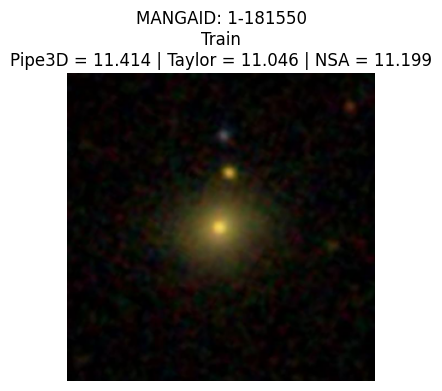

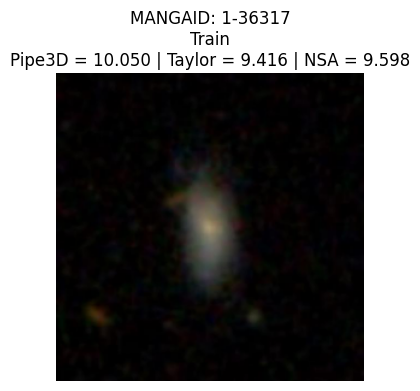

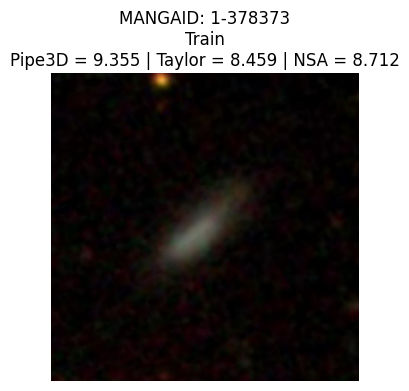

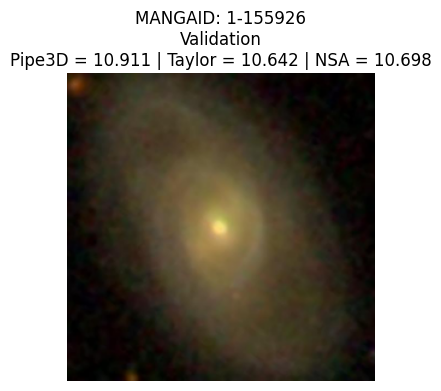

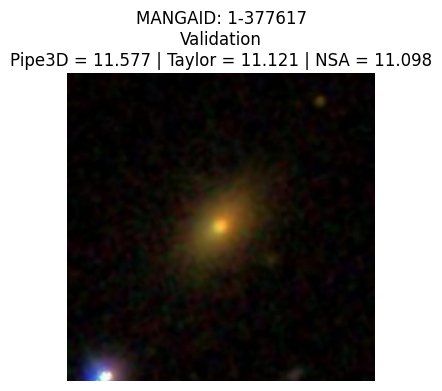

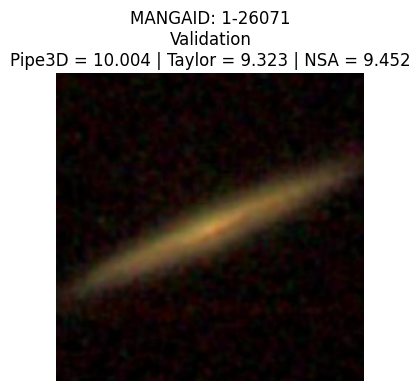

In [25]:
# ============================================================
# ETAPA 20 — VERIFICACIÓN VISUAL IMAGEN + TARGETS
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Incorporar la partición experimental congelada
# ------------------------------------------------------------

datos_experimento = (
    datos_experimento
    .drop(columns=["_merge"])
    .merge(
        tabla_splits[
            [
                "mangaid",
                "particion",
                "pipe3d_extremo_sensibilidad"
            ]
        ],
        on="mangaid",
        how="left",
        validate="one_to_one"
    )
)


# ------------------------------------------------------------
# 2. Verificar asignación de particiones
# ------------------------------------------------------------

print("=== PARTICIONES INCORPORADAS ===")

print(
    datos_experimento["particion"]
    .value_counts()
)

assert datos_experimento["particion"].isna().sum() == 0


# ------------------------------------------------------------
# 3. Seleccionar ejemplos reproducibles
#    SOLO Train y Validation
# ------------------------------------------------------------

muestra_train = (
    datos_experimento[
        datos_experimento["particion"] == "Train"
    ]
    .sample(
        n=3,
        random_state=SEED_BASE
    )
)

muestra_val = (
    datos_experimento[
        datos_experimento["particion"] == "Validation"
    ]
    .sample(
        n=3,
        random_state=SEED_BASE
    )
)

muestra_visual = pd.concat(
    [
        muestra_train,
        muestra_val
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 4. Mostrar información tabular
# ------------------------------------------------------------

print("\n=== GALAXIAS SELECCIONADAS ===")

display(
    muestra_visual[
        [
            "mangaid",
            "particion",
            "Pipe3D",
            "Taylor",
            "NSA",
            "pipe3d_extremo_sensibilidad"
        ]
    ].round(4)
)


# ------------------------------------------------------------
# 5. Visualizar una por una
# ------------------------------------------------------------

for _, fila in muestra_visual.iterrows():

    plt.figure(figsize=(4, 4))

    plt.imshow(fila["images"])

    plt.title(
        f"MANGAID: {fila['mangaid']}\n"
        f"{fila['particion']}\n"
        f"Pipe3D = {fila['Pipe3D']:.3f} | "
        f"Taylor = {fila['Taylor']:.3f} | "
        f"NSA = {fila['NSA']:.3f}"
    )

    plt.axis("off")
    plt.show()

## Etapa 21 — Construcción de un Dataset común para Pipe3D, Taylor y NSA

### ¿Qué hago?

Construyo una única clase `Dataset` de PyTorch capaz de utilizar cualquiera de las tres estimaciones de masa como variable objetivo:

$$
y\in
\{
M_{\mathrm{Pipe3D}},
M_{\mathrm{Taylor}},
M_{\mathrm{NSA}}
\}
$$

La imagen asociada a cada galaxia permanecerá exactamente igual.

La única diferencia entre los tres datasets será la columna utilizada como `target`.

---

### ¿Por qué lo hago?

Una posibilidad sería crear tres clases distintas:

- Dataset Pipe3D;
- Dataset Taylor;
- Dataset NSA.

Sin embargo, esto introduciría código duplicado.

El código duplicado aumenta el riesgo de producir diferencias accidentales entre experimentos, por ejemplo:

- transformaciones distintas;
- diferentes tipos numéricos;
- cambios en el orden de las galaxias;
- diferentes campos devueltos por el Dataset.

Para una comparación controlada es preferible utilizar una sola implementación.

Conceptualmente queremos:

$$
Dataset(X,y_{\mathrm{Pipe3D}})
$$

$$
Dataset(X,y_{\mathrm{Taylor}})
$$

$$
Dataset(X,y_{\mathrm{NSA}})
$$

donde:

$$
X_{\mathrm{Pipe3D}}
=
X_{\mathrm{Taylor}}
=
X_{\mathrm{NSA}}
$$

---

### Teoría detrás

PyTorch utiliza la clase `Dataset` para definir cómo recuperar una observación individual.

Para un índice $i$, el método:

`__getitem__(i)`

debe devolver al menos:

$$
(X_i,y_i)
$$

En nuestro caso también devolveremos:

$$
MANGAID_i
$$

para mantener trazabilidad.

La imagen original es un objeto PIL RGB de:

$$
256\times256
$$

y `ToTensor()` la transforma en un tensor:

$$
X_i\in\mathbb{R}^{3\times256\times256}
$$

con valores de píxel aproximadamente en:

$$
[0,1]
$$

La masa se convertirá explícitamente a `float32`, que es el tipo numérico utilizado habitualmente durante el entrenamiento de redes neuronales.

El target tendrá forma:

$$
[1]
$$

para que posteriormente un batch de 32 galaxias produzca:

$$
y\in\mathbb{R}^{32\times1}
$$

que coincide con la salida de:

`Linear(2048,1)`.

---

### ¿Cómo lo implemento?

La clase recibirá:

1. el DataFrame con imágenes y masas;
2. el nombre del target;
3. la transformación de imagen.

Solo se permitirán tres targets:

- `Pipe3D`;
- `Taylor`;
- `NSA`.

Cada elemento devolverá:

- `image`;
- `target`;
- `mangaid`.

Después se crearán datasets de Train y Validation para los tres targets utilizando exactamente las mismas galaxias.

Finalmente se comprobará que:

$$
X_i^{Pipe3D}
=
X_i^{Taylor}
=
X_i^{NSA}
$$

para la misma galaxia, mientras cambia únicamente su etiqueta.

In [26]:
# ============================================================
# ETAPA 21 — DATASET COMÚN PARA LOS TRES TARGETS
# ============================================================

import torch
from torch.utils.data import Dataset
from torchvision import transforms


# ------------------------------------------------------------
# 1. Transformación común
# ------------------------------------------------------------

transform_katachi = transforms.Compose([
    transforms.ToTensor()
])


# ------------------------------------------------------------
# 2. Dataset parametrizable
# ------------------------------------------------------------

class KatachiMassDataset(Dataset):

    TARGETS_VALIDOS = {
        "Pipe3D",
        "Taylor",
        "NSA"
    }

    def __init__(
        self,
        dataframe,
        target_col,
        transform=None
    ):

        if target_col not in self.TARGETS_VALIDOS:
            raise ValueError(
                f"Target inválido: {target_col}. "
                f"Opciones: {self.TARGETS_VALIDOS}"
            )

        # Reset del índice SOLO para acceso interno consistente.
        # No modifica mangaid.
        self.df = dataframe.reset_index(drop=True)

        self.target_col = target_col
        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        fila = self.df.iloc[idx]

        imagen = fila["images"]

        if self.transform is not None:
            imagen = self.transform(imagen)

        target = torch.tensor(
            [float(fila[self.target_col])],
            dtype=torch.float32
        )

        mangaid = str(
            fila["mangaid"]
        )

        return {
            "image": imagen,
            "target": target,
            "mangaid": mangaid
        }


# ------------------------------------------------------------
# 3. Construir DataFrames según el split CONGELADO
# ------------------------------------------------------------

df_train_final = (
    datos_experimento[
        datos_experimento["particion"] == "Train"
    ]
    .sort_values("mangaid")
    .reset_index(drop=True)
)

df_val_final = (
    datos_experimento[
        datos_experimento["particion"] == "Validation"
    ]
    .sort_values("mangaid")
    .reset_index(drop=True)
)


print("=== DATAFRAMES PARA PYTORCH ===")
print("Train:", len(df_train_final))
print("Validation:", len(df_val_final))


# ------------------------------------------------------------
# 4. Crear datasets Train
# ------------------------------------------------------------

train_pipe3d = KatachiMassDataset(
    df_train_final,
    target_col="Pipe3D",
    transform=transform_katachi
)

train_taylor = KatachiMassDataset(
    df_train_final,
    target_col="Taylor",
    transform=transform_katachi
)

train_nsa = KatachiMassDataset(
    df_train_final,
    target_col="NSA",
    transform=transform_katachi
)


# ------------------------------------------------------------
# 5. Crear datasets Validation
# ------------------------------------------------------------

val_pipe3d = KatachiMassDataset(
    df_val_final,
    target_col="Pipe3D",
    transform=transform_katachi
)

val_taylor = KatachiMassDataset(
    df_val_final,
    target_col="Taylor",
    transform=transform_katachi
)

val_nsa = KatachiMassDataset(
    df_val_final,
    target_col="NSA",
    transform=transform_katachi
)


# ------------------------------------------------------------
# 6. Verificar tamaños
# ------------------------------------------------------------

assert len(train_pipe3d) == 6510
assert len(train_taylor) == 6510
assert len(train_nsa) == 6510

assert len(val_pipe3d) == 1149
assert len(val_taylor) == 1149
assert len(val_nsa) == 1149


# ------------------------------------------------------------
# 7. Inspeccionar la MISMA galaxia con los tres targets
# ------------------------------------------------------------

i = 0

ej_pipe3d = train_pipe3d[i]
ej_taylor = train_taylor[i]
ej_nsa = train_nsa[i]


print("\n=== MISMA GALAXIA, TRES TARGETS ===")

print(
    "MANGAID Pipe3D:",
    ej_pipe3d["mangaid"]
)

print(
    "MANGAID Taylor:",
    ej_taylor["mangaid"]
)

print(
    "MANGAID NSA:",
    ej_nsa["mangaid"]
)

print(
    "\nShape imagen:",
    ej_pipe3d["image"].shape
)

print(
    "Dtype imagen:",
    ej_pipe3d["image"].dtype
)

print(
    "Rango píxeles:",
    float(ej_pipe3d["image"].min()),
    "a",
    float(ej_pipe3d["image"].max())
)

print(
    "\nPipe3D:",
    ej_pipe3d["target"].item()
)

print(
    "Taylor:",
    ej_taylor["target"].item()
)

print(
    "NSA:",
    ej_nsa["target"].item()
)


# ------------------------------------------------------------
# 8. Verificar que las imágenes sean EXACTAMENTE iguales
# ------------------------------------------------------------

assert (
    ej_pipe3d["mangaid"]
    ==
    ej_taylor["mangaid"]
    ==
    ej_nsa["mangaid"]
)

assert torch.equal(
    ej_pipe3d["image"],
    ej_taylor["image"]
)

assert torch.equal(
    ej_pipe3d["image"],
    ej_nsa["image"]
)


print(
    "\n✓ La misma galaxia utiliza exactamente la misma imagen."
)

print(
    "✓ Solamente cambia el target."
)

=== DATAFRAMES PARA PYTORCH ===
Train: 6510
Validation: 1149

=== MISMA GALAXIA, TRES TARGETS ===
MANGAID Pipe3D: 1-1009
MANGAID Taylor: 1-1009
MANGAID NSA: 1-1009

Shape imagen: torch.Size([3, 256, 256])
Dtype imagen: torch.float32
Rango píxeles: 0.0 a 0.9882352948188782

Pipe3D: 11.178438186645508
Taylor: 10.537899017333984
NSA: 10.517011642456055

✓ La misma galaxia utiliza exactamente la misma imagen.
✓ Solamente cambia el target.
